# 25_01 — Datos reales y preprocesamiento · BTCUSDT a 5 minutos (Binance)

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: **este notebook** lee las velas de 5 min, arma la curva diaria, ajusta base + FPCA (**sin estandarizar los scores**) y escribe los datasets AR
- 02: `psbp_fd_iteracion.m` muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento
- 03, 04, 05: `25_03_convergencia` / `25_04_evaluacion` / `25_05_comparacion`

Las celdas **`[CONFIG]`** son las únicas que se tocan al cambiar de corrida.

> **Diseño de la corrida 25**: el del 24 sobre otra serie.
> - covariables: **sólo rezago propio**, $\xi_{k,t-1},\dots,\xi_{k,t-N_{LAGS}}$; se entrena una sola vez en $M=$`M_ENTRENO` y los $M$ menores reutilizan sus trazas (`hyperparameters.json["trazas_en"]`);
> - gating calibrado por **dispersión** del argumento probit + inclusión `apij=1, bpij=5` (Chung & Dunson);
> - objetivo de evaluación: **curva suavizada** (docs §03_05_00).
>
> Cambia la carga y la curva (§2): cada día UTC es una curva de 288 barras. `CURVA` (§1.1) elige entre el retorno acumulado $X_t(\tau_m)=\log C_{t,m}-\log O_{t,1}$ y la log-volatilidad de Parkinson por barra; cada curva escribe en su propia `VENTANA_ID`. Sus cifras **no** son comparables con las de 21-24 (otra serie, otra grilla).

## 1. Imports y rutas

In [1]:
import json
import math
import sys
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Contrato de artefactos: mismos escritores que en simulación
from model_psbp_fd.pipelines import (
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines, mise
# Rutas del contrato: el gemelo Python de config_paths.m.
from model_psbp_fd.utils import (
    get_project_root, normalizar_lista_M, construir_paths,
    guardar_en_todos, replicar_figura, pesos_trapezoidales,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# [CONFIG] debe coincidir con 25_03, 25_04, 25_05 y con psbp_fd_iteracion.m
BASENAME     = "real"
SERIE_ID     = "btcusdt"  # par modelado

# Curva diaria (§2.1). Cada curva tiene su VENTANA_ID: no se pisan artefactos.
CURVAS_VENTANA = {"retorno_acumulado": 1, "log_parkinson": 2,
                  "log_precio": 3, "retorno_barra": 4}
CURVA        = "retorno_acumulado"
VENTANA_ID   = CURVAS_VENTANA[CURVA]   # 25_03/04/05 y el .m declaran este mismo valor
SEED         = 41232      # semilla base; MATLAB la LEE de hyperparameters.json

# [BARRIDO] componentes FPCA retenidas; igual en los cuatro notebooks.
M_FPCA_LIST = (1, 2, 3, 4)

LIMPIAR_DIRECTORIOS = True

M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
M_ENTRENO       = max(M_FPCA_LIST)   # único M que se entrena en MATLAB
EXPERIMENT_BASE = f"{BASENAME}_{SERIE_ID}_v{VENTANA_ID:02d}"


def eid_de(M: int) -> str:
    """real_<serie>_v<ventana a 2 digitos>_m<M a 2 digitos>"""
    return f"{EXPERIMENT_BASE}_m{int(M):02d}"


print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"serie {SERIE_ID} · curva {CURVA} -> ventana {VENTANA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}   (se entrena solo M={M_ENTRENO})")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {eid_de(_M)}")

PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : real_btcusdt_v01
serie btcusdt · curva retorno_acumulado -> ventana 1 · seed base 41232
barrido en M    : [1, 2, 3, 4]   (se entrena solo M=4)
   M=1  ->  real_btcusdt_v01_m01
   M=2  ->  real_btcusdt_v01_m02
   M=3  ->  real_btcusdt_v01_m03
   M=4  ->  real_btcusdt_v01_m04


In [3]:
PATHS_POR_M = {M: construir_paths(eid_de(M), dominio="reales",
                                  project_root=PROJECT_ROOT,
                                  limpiar=LIMPIAR_DIRECTORIOS)
               for M in M_FPCA_LIST}

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({eid_de(M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (real_btcusdt_v01_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\real_btcusdt_v01_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\real_btcusdt_v01_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\predict\real_btcusdt_v01_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\reales\real_btcusdt_v01_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\reales\real_btcusdt_v01_m01
M=2  (real_btcusdt_v01_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\raw\real_btcusdt_v01_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\processed\functional\real_btcusdt_v01_m02
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\reales\pr

## 2. Datos

### 2.1 `[CONFIG]` Fuente, curva y rango de fechas

Velas (klines) de 5 min de Binance, en UTC. Cada **día UTC** es una curva de 288 barras sobre $\tau\in[0,1]$. El mercado opera 24/7: no hay salto nocturno ni ancla que agregar. `CURVA` se declara en §1.1.

| `CURVA` | $X_t(\tau_m)$, $m=1,\dots,288$ | uso |
|---|---|---|
| `"retorno_acumulado"` | $\log C_{t,m}-\log O_{t,1}$ | **principal** (ventana 1) |
| `"log_parkinson"` | $\log\hat\sigma_{t,m}$, $\hat\sigma_{t,m}=(\log H_{t,m}-\log L_{t,m})/\sqrt{4\log 2}$ | **volatilidad intradía** (ventana 2) |
| `"log_precio"` | $\log C_{t,m}$ | referencia: el nivel del test cae fuera del rango de train |
| `"retorno_barra"` | $\log C_{t,m}-\log C_{t,m-1}$, con $C_{t,0}=O_{t,1}$ | referencia: casi ruido |

$C_{t,m}$, $H_{t,m}$, $L_{t,m}$ son el cierre, máximo y mínimo de la barra $m$ del día $t$, y $O_{t,1}$ la apertura del día. En Parkinson, una barra con $H=L$ (sin transacciones) no tiene rango: queda ausente y se interpola en log-volatilidad. `FECHA_INICIO` / `FECHA_FIN` (inclusivas, UTC) fijan el rango; $T$ es el número de días que quedan tras descartar los incompletos.

In [4]:
DIR_BINANCE = PROJECT_ROOT / "data" / "reales" / "raw" / "cripto_binance"
PAR, INTERVALO = "BTCUSDT", "5m"
ARCHIVOS_ANUALES = sorted((DIR_BINANCE / PAR / INTERVALO / "anual")
                          .glob(f"{PAR}-{INTERVALO}-*.csv"))
ARCHIVO_CONSOLIDADO = DIR_BINANCE / "BTCUSDT_5m_20200101_20260831.csv"   # solo contraste

# Klines de Binance: sin header, 12 columnas.
COLUMNAS = ["open_time", "open", "high", "low", "close", "volume", "close_time",
            "quote_volume", "n_trades", "taker_buy_base", "taker_buy_quote", "ignore"]

# -- Curva (CURVA se declara en §1.1) -----------------------------------------------
CURVAS = {"retorno_acumulado": "retorno log acumulado intradía",
          "log_parkinson":     "log-volatilidad de Parkinson por barra",
          "log_precio":        "log-precio de cierre",
          "retorno_barra":     "retorno log por barra"}
assert set(CURVAS) == set(CURVAS_VENTANA)
VARIABLE = CURVAS[CURVA]

# -- Rango de fechas (UTC) ------------------------------------------------------
FECHA_INICIO = "2020-01-01"
FECHA_FIN    = "2026-08-31"      # inclusiva; None = ultimo dia disponible
PROP_TRAIN   = 0.70              # T0 = floor(PROP_TRAIN * T)

# -- Esquema de observacion ------------------------------------------------------
BARRAS_DIA    = 288              # G: 24 h en barras de 5 min
PASO          = pd.Timedelta(days=1) / BARRAS_DIA
MAX_HUECO_DIA = 0.20             # dias con mas del 20 % de barras ausentes se descartan

assert CURVA in CURVAS, f"CURVA admitida: {list(CURVAS)}"
assert ARCHIVOS_ANUALES, f"No hay CSV anuales en {DIR_BINANCE / PAR / INTERVALO / 'anual'}"
print(f"archivos : {[r.name for r in ARCHIVOS_ANUALES]}")
print(f"curva    : {CURVA}  ({VARIABLE})")
print(f"rango    : {FECHA_INICIO}  ...  {FECHA_FIN or 'fin de los datos'}   ·   paso {PASO}")

archivos : ['BTCUSDT-5m-2020.csv', 'BTCUSDT-5m-2021.csv', 'BTCUSDT-5m-2022.csv', 'BTCUSDT-5m-2023.csv', 'BTCUSDT-5m-2024.csv', 'BTCUSDT-5m-2025.csv', 'BTCUSDT-5m-2026.csv']
curva    : retorno_acumulado  (retorno log acumulado intradía)
rango    : 2020-01-01  ...  2026-08-31   ·   paso 0 days 00:05:00


### 2.2 Lectura, control de calidad y matriz por día

La unidad de `open_time` cambia entre archivos (milisegundos hasta 2024, microsegundos desde 2025) y se detecta por archivo. Las barras con volumen 0 son barras sin transacciones, no errores: se conservan. Los huecos se interpolan en el log-precio dentro de cada día.

In [5]:
def leer_klines_anual(ruta):
    """CSV anual de Binance -> (DataFrame con tiempos UTC, unidad detectada)."""
    d = pd.read_csv(ruta, header=None, names=COLUMNAS)
    es_us = d["open_time"] > 1e14
    assert es_us.all() or not es_us.any(), f"{ruta.name}: unidades de tiempo mezcladas."
    unidad = "us" if es_us.iloc[0] else "ms"
    for c in ("open_time", "close_time"):
        d[c] = pd.to_datetime(d[c], unit=unidad, utc=True)
    anio = int(ruta.stem.rsplit("-", 1)[1])
    assert d["open_time"].iloc[0].year == anio, (
        f"{ruta.name}: la primera fila es de {d['open_time'].iloc[0].year}, no de {anio}.")
    return d, unidad


_partes, UNIDADES = [], {}
for _r in ARCHIVOS_ANUALES:
    _d, UNIDADES[_r.name] = leer_klines_anual(_r)
    _partes.append(_d)
kl = pd.concat(_partes, ignore_index=True).sort_values("open_time").reset_index(drop=True)

print(f"filas leidas : {len(kl)}   ·   unidades: {UNIDADES}")
print(f"cobertura    : {kl['open_time'].min()}  ...  {kl['open_time'].max()}")

_dup = int(kl["open_time"].duplicated().sum())
assert _dup == 0, f"{_dup} open_time duplicados."
assert (kl["open_time"] == kl["open_time"].dt.floor(PASO)).all(), "open_time fuera de la grilla de 5 min."

# -- Huecos, barras sin transacciones y barras cortadas ---------------------------
_dif = kl["open_time"].diff()
_hue = _dif[_dif > PASO]
HUECOS = (pd.DataFrame({"anio": kl.loc[_hue.index, "open_time"].dt.year.to_numpy(),
                        "min_ausentes": ((_hue - PASO).dt.total_seconds() / 60).to_numpy()})
          .groupby("anio")["min_ausentes"].agg(saltos="size", max_min="max", total_min="sum"))
display(HUECOS.style.set_caption("Huecos entre barras consecutivas (minutos ausentes)"))
_vol0 = kl.loc[kl["volume"] == 0, "open_time"].dt.year.value_counts().sort_index()
_dur  = kl["close_time"] - kl["open_time"]
_irreg = int(((_dur < PASO - pd.Timedelta(milliseconds=1)) | (_dur >= PASO)).sum())
print(f"barras con volumen 0 (sin transacciones, se conservan): {_vol0.to_dict()}")
print(f"barras con close_time irregular (bordes de caidas del servicio, se conservan): {_irreg}")

# -- Contraste con el consolidado ------------------------------------------------
_c = pd.read_csv(ARCHIVO_CONSOLIDADO)
for c in ("open_time", "close_time"):
    _c[c] = pd.to_datetime(_c[c], utc=True, format="ISO8601")
_m = kl.merge(_c, on="open_time", how="outer", suffixes=("", "_cons"), indicator=True)
_amb = _m[_m["_merge"] == "both"]
CONTRASTE = pd.DataFrame(
    [{"columna": col,
      "filas_distintas": int((_amb[col] != _amb[f"{col}_cons"]).sum()),
      "max_abs_dif": (float(np.abs(_amb[col] - _amb[f"{col}_cons"]).max())
                      if col != "close_time" else np.nan)}
     for col in ("open", "high", "low", "close", "volume", "close_time", "quote_volume",
                 "n_trades", "taker_buy_base", "taker_buy_quote")]).set_index("columna")
print(f"\nanuales {len(kl)} filas · consolidado {len(_c)} · solo en anuales "
      f"{int((_m['_merge'] == 'left_only').sum())} · solo en consolidado "
      f"{int((_m['_merge'] == 'right_only').sum())}")
display(CONTRASTE.style.format({"max_abs_dif": "{:.3e}"}, na_rep="-")
        .set_caption("Anuales vs consolidado, filas comunes"))
_iguales = CONTRASTE.loc[["open", "high", "low", "close", "close_time"], "filas_distintas"].sum() == 0
print("precios y marcas de tiempo: " + ("identicos" if _iguales else "DIFIEREN, revisar"))

# -- Rango pedido y matriz (dia UTC x barra) --------------------------------------
_ini = pd.Timestamp(FECHA_INICIO, tz="UTC")
_fin = (pd.Timestamp(FECHA_FIN, tz="UTC") + pd.Timedelta(days=1) if FECHA_FIN is not None
        else kl["open_time"].max().floor("D") + pd.Timedelta(days=1))    # limite exclusivo
assert _fin > _ini, f"FECHA_FIN ({FECHA_FIN}) debe ser posterior a FECHA_INICIO ({FECHA_INICIO})."
_v = kl.loc[(kl["open_time"] >= _ini) & (kl["open_time"] < _fin)].copy()
assert len(_v) > 0, f"El rango [{_ini}, {_fin}) no contiene datos."
_v["dia"]   = _v["open_time"].dt.floor("D")
_v["barra"] = ((_v["open_time"] - _v["dia"]) / PASO).astype(int)

_dias_cal = pd.date_range(_ini, _fin - pd.Timedelta(days=1), freq="D")
LOG_C = np.log(_v.pivot(index="dia", columns="barra", values="close")
               .reindex(index=_dias_cal, columns=range(BARRAS_DIA)))
LOG_O = np.log(_v.pivot(index="dia", columns="barra", values="open")
               .reindex(index=_dias_cal, columns=range(BARRAS_DIA)))
LOG_H = np.log(_v.pivot(index="dia", columns="barra", values="high")
               .reindex(index=_dias_cal, columns=range(BARRAS_DIA)))
LOG_L = np.log(_v.pivot(index="dia", columns="barra", values="low")
               .reindex(index=_dias_cal, columns=range(BARRAS_DIA)))

_frac_dia   = LOG_C.isna().mean(axis=1)
_dias_malos = _frac_dia[_frac_dia > MAX_HUECO_DIA]
DESCARTES = pd.DataFrame({
    "dia": [str(d.date()) for d in _dias_malos.index],
    "frac_ausente": _dias_malos.to_numpy(),
    "motivo": ["sin datos" if f == 1 else f"> {MAX_HUECO_DIA:.0%} de barras ausentes"
               for f in _dias_malos]})
LOG_C = LOG_C.drop(index=_dias_malos.index)
LOG_O = LOG_O.drop(index=_dias_malos.index)
LOG_H = LOG_H.drop(index=_dias_malos.index)     # sin interpolar: el rango se arma en §2.3
LOG_L = LOG_L.drop(index=_dias_malos.index)
_na_antes = int(LOG_C.isna().sum().sum())
_sin_apertura = int(LOG_O.iloc[:, 0].isna().sum())
LOG_C = LOG_C.interpolate(axis=1, limit_direction="both")    # lineal en log-precio, dentro del dia
LOG_O = LOG_O.interpolate(axis=1, limit_direction="both")
assert not (LOG_C.isna().any().any() or LOG_O.isna().any().any()), "Quedan NaN tras la interpolacion."

print(f"\ndias calendario: {len(_dias_cal)}   descartados: {len(DESCARTES)}")
if len(DESCARTES):
    display(DESCARTES)
print(f"barras interpoladas en los dias retenidos: {_na_antes}  "
      f"({_na_antes / LOG_C.size:.4%})  ·  dias sin barra 00:00: {_sin_apertura}")

filas leidas : 700818   ·   unidades: {'BTCUSDT-5m-2020.csv': 'ms', 'BTCUSDT-5m-2021.csv': 'ms', 'BTCUSDT-5m-2022.csv': 'ms', 'BTCUSDT-5m-2023.csv': 'ms', 'BTCUSDT-5m-2024.csv': 'ms', 'BTCUSDT-5m-2025.csv': 'us', 'BTCUSDT-5m-2026.csv': 'us'}
cobertura    : 2020-01-01 00:00:00+00:00  ...  2026-08-31 23:55:00+00:00


,saltos,max_min,total_min
anio,,,
2020,8,350.000000,1245.000000
2021,6,280.000000,985.000000
2023,1,80.000000,80.000000


barras con volumen 0 (sin transacciones, se conservan): {2020: 10, 2021: 18, 2023: 14}
barras con close_time irregular (bordes de caidas del servicio, se conservan): 8

anuales 700818 filas · consolidado 700818 · solo en anuales 0 · solo en consolidado 0


,filas_distintas,max_abs_dif
columna,,
open,0,0.000e+00
high,0,0.000e+00
low,0,0.000e+00
close,0,0.000e+00
volume,0,0.000e+00
close_time,0,-
quote_volume,24,5.960e-08
n_trades,0,0.000e+00
taker_buy_base,0,0.000e+00


precios y marcas de tiempo: identicos

dias calendario: 2435   descartados: 1


,dia,frac_ausente,motivo
0,2020-02-19,0.243056,> 20% de barras ausentes


barras interpoladas en los dias retenidos: 392  (0.0559%)  ·  dias sin barra 00:00: 0


In [6]:
# -- Curva segun CURVA -------------------------------------------------------------
_lc, _lo = LOG_C.to_numpy(dtype=float), LOG_O.to_numpy(dtype=float)
R_BARRA = np.diff(np.column_stack([_lo[:, 0], _lc]), axis=1)     # retorno log por barra
if CURVA == "retorno_acumulado":
    X_raw = _lc - _lo[:, [0]]
elif CURVA == "log_parkinson":
    # Rango de la barra sin interpolar; H = L (sin transacciones) o barra ausente -> NaN,
    # que se interpola en log-volatilidad dentro del dia.
    _rango = (LOG_H - LOG_L).where(lambda z: z > 0)
    _sin_rango = int(_rango.isna().sum().sum())
    X_raw = ((np.log(_rango) - 0.5 * np.log(4 * np.log(2)))
             .interpolate(axis=1, limit_direction="both").to_numpy(dtype=float))
    print(f"barras sin rango (H = L o ausentes), interpoladas en log-vol: {_sin_rango}")
elif CURVA == "log_precio":
    X_raw = _lc
else:
    X_raw = R_BARRA
VOL_DIA = (R_BARRA ** 2).sum(axis=1)       # volatilidad realizada del dia (diagnostico)

# -- Continuidad temporal: un dia ausente hace que el rezago l no sea t-l ------------
_idx    = pd.Series(LOG_C.index)
_saltos = int((_idx.diff().dt.days.dropna() != 1).sum())
print(f"saltos en la secuencia de dias modelados: {_saltos}"
      + ("   <- el rezago l no siempre es el dia t-l; declararlo al reportar"
         if _saltos else "   (serie diaria continua)"))

T, G   = X_raw.shape
assert G == BARRAS_DIA
grilla = np.linspace(0.0, 1.0, G)             # tau_1 = 0 ... tau_G = 1
DIAS   = LOG_C.index.tz_convert(None).to_numpy()

print(f"curvas   : X_raw {X_raw.shape}   (T={T} dias, G={G} barras por dia)")
print(f"periodo  : {pd.Timestamp(DIAS[0]).date()}  ...  {pd.Timestamp(DIAS[-1]).date()}")
print(f"particion: T0 = {int(np.floor(PROP_TRAIN * T))}, test = {T - int(np.floor(PROP_TRAIN * T))}")
print(f"rango de {VARIABLE}: [{X_raw.min():.4f}, {X_raw.max():.4f}]  media {X_raw.mean():+.2e}")

# -- Diagnostico de la serie -------------------------------------------------------
def _acf1(x):
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])

_nivel = X_raw.mean(axis=1)                  # media diaria de la curva
diagnostico = {
    "T": int(T), "G": int(G), "curva": CURVA,
    "acf1_nivel_diario":      round(_acf1(_nivel), 6),
    "acf1_retorno_diario":    round(_acf1(_lc[:, -1] - _lo[:, 0]), 6),
    "acf1_vol_realizada":     round(_acf1(VOL_DIA), 6),
    "sd_entre_dias":          round(float(_nivel.std(ddof=1)), 6),
    "sd_intra_dia_media":     round(float(X_raw.std(axis=1, ddof=1).mean()), 6),
    "razon_intra_entre":      round(float(X_raw.std(axis=1, ddof=1).mean() / _nivel.std(ddof=1)), 6),
    "asimetria_nivel":        round(float(pd.Series(_nivel).skew()), 6),
    "exceso_curtosis_nivel":  round(float(pd.Series(_nivel).kurt()), 6),
    "dias_descartados":       int(len(DESCARTES)),
    "saltos_secuencia_dias":  int(_saltos),
    "duplicados_open_time":   int(_dup),
    "barras_interpoladas":    int(_na_antes),
    "barras_volumen_cero":    int(_vol0.sum()),
    "unidades_open_time":     UNIDADES,
}
print("\nDiagnostico de la serie observada:")
for k, v in diagnostico.items():
    print(f"  {k:24s} = {v}")

saltos en la secuencia de dias modelados: 1   <- el rezago l no siempre es el dia t-l; declararlo al reportar
curvas   : X_raw (2434, 288)   (T=2434 dias, G=288 barras por dia)
periodo  : 2020-01-01  ...  2026-08-31
particion: T0 = 1703, test = 731
rango de retorno log acumulado intradía: [-0.5414, 0.2140]  media +2.31e-04

Diagnostico de la serie observada:
  T                        = 2434
  G                        = 288
  curva                    = retorno_acumulado
  acf1_nivel_diario        = -0.087427
  acf1_retorno_diario      = -0.071078
  acf1_vol_realizada       = 0.418079
  sd_entre_dias            = 0.017237
  sd_intra_dia_media       = 0.009821
  razon_intra_entre        = 0.56978
  asimetria_nivel          = -0.826915
  exceso_curtosis_nivel    = 10.015277
  dias_descartados         = 1
  saltos_secuencia_dias    = 1
  duplicados_open_time     = 0
  barras_interpoladas      = 392
  barras_volumen_cero      = 42
  unidades_open_time       = {'BTCUSDT-5m-2020.csv': 'ms', '

### 2.3 Visualización de la serie funcional

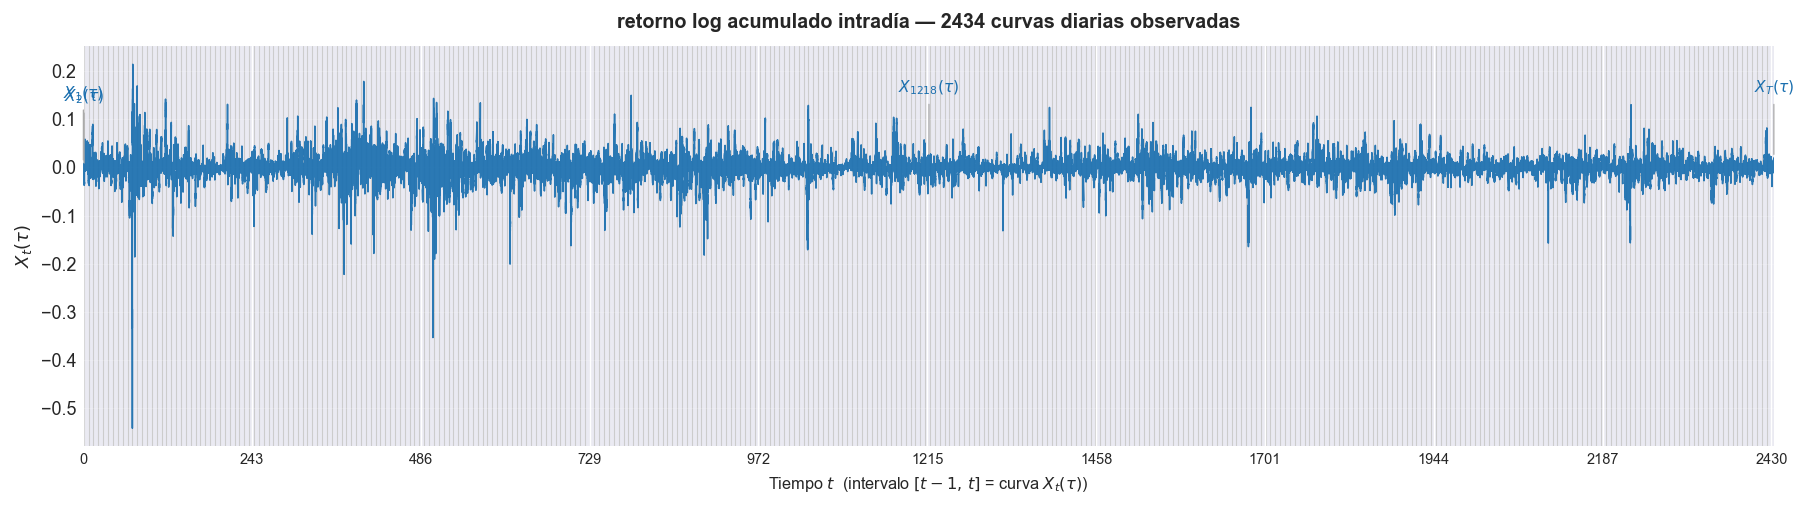

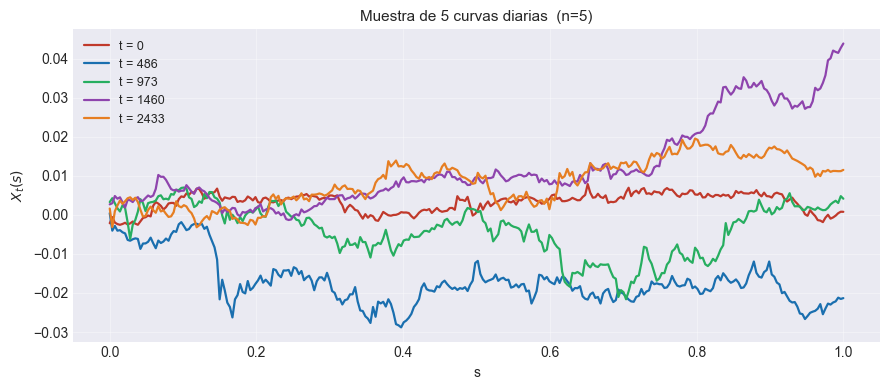

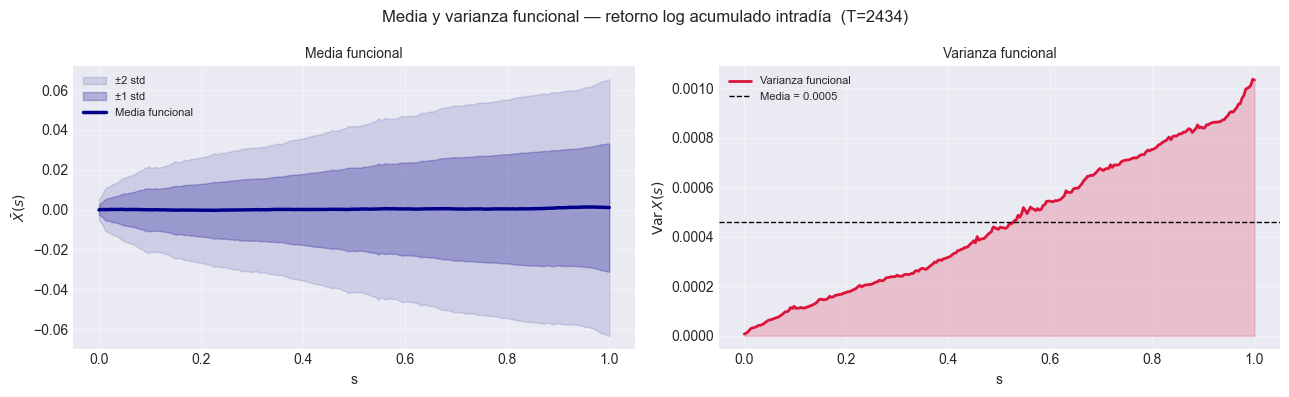

In [7]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=7,
    title=f"{VARIABLE} — {T} curvas diarias observadas")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, T // 5, 2 * T // 5, 3 * T // 5, T - 1],
    title="Muestra de 5 curvas diarias")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title=f"Media y varianza funcional — {VARIABLE}")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

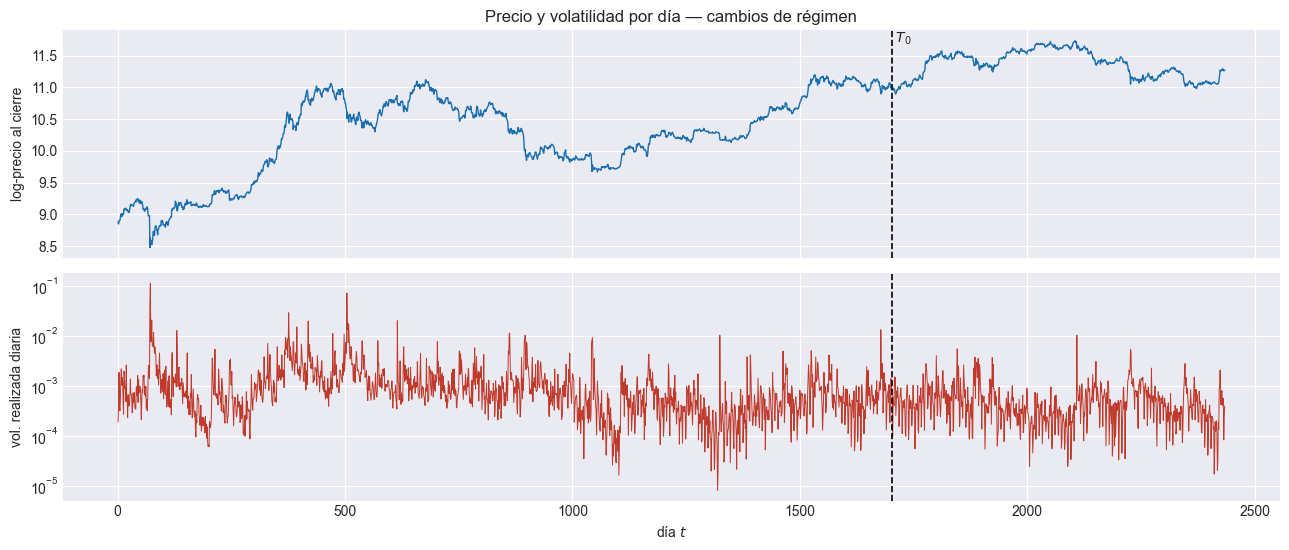

Por tercio de la muestra:  media de la curva · sd · vol. realizada media
  tercio 1: +0.00044  (sd 0.02272)  ·  vol 2.026e-03
  tercio 2: +0.00015  (sd 0.01451)  ·  vol 8.086e-04
  tercio 3: +0.00011  (sd 0.01285)  ·  vol 6.158e-04
log-precio train [8.264, 11.207]  test [10.873, 11.744]


In [8]:
# Precio y volatilidad por dia con el corte train/test: el regimen de BTC vive en
# el nivel y en la escala, no en la curva de retorno.
_T0_prev = int(np.floor(PROP_TRAIN * T))

fig, axes = plt.subplots(2, 1, figsize=(13, 5.6), sharex=True)
axes[0].plot(np.arange(1, T + 1), _lc[:, -1], lw=1.0, color="#1a6faf")
axes[0].set_ylabel("log-precio al cierre")
axes[1].plot(np.arange(1, T + 1), VOL_DIA, lw=0.7, color="#c0392b")
axes[1].set_yscale("log")
axes[1].set_ylabel("vol. realizada diaria")
for ax in axes:
    ax.axvline(_T0_prev, color="k", ls="--", lw=1.2)
axes[0].text(_T0_prev, axes[0].get_ylim()[1], r" $T_0$", va="top", fontsize=10)
axes[1].set_xlabel("día $t$")
axes[0].set_title("Precio y volatilidad por día — cambios de régimen")
fig.tight_layout()
replicar_figura("04_serie_diaria.png", PATHS_POR_M, fig=fig)
plt.show()

print("Por tercio de la muestra:  media de la curva · sd · vol. realizada media")
for i, (_n3, _v3) in enumerate(zip(np.array_split(_nivel, 3), np.array_split(VOL_DIA, 3)), 1):
    print(f"  tercio {i}: {_n3.mean():+.5f}  (sd {_n3.std(ddof=1):.5f})  ·  vol {_v3.mean():.3e}")
print(f"log-precio train [{_lc[:_T0_prev].min():.3f}, {_lc[:_T0_prev].max():.3f}]  "
      f"test [{_lc[_T0_prev:].min():.3f}, {_lc[_T0_prev:].max():.3f}]")

### 2.4 Persistencia de curvas

Sólo `X_curves.npy` (la curva de `CURVA`): **no** hay `X_curves_true.npy` porque no hay curva sin ruido. El objetivo de evaluación es la **curva suavizada** (§3.2), que `_04`/`_05` reconstruyen desde la representación B-spline.

In [9]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla)      # sin X_true: no existe
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}   (replicado en {len(PATHS_POR_M)} directorios)")

# Análogo real de simulation_config.json. Lo lee 25_05 para documentar la fuente.
for _M, _p in PATHS_POR_M.items():
    dataset_config = {
        "fuente":        [str(r) for r in ARCHIVOS_ANUALES],
        "mercado":       f"Binance spot {PAR} {INTERVALO}, UTC",
        "curva":         CURVA,
        "variable":      VARIABLE,
        "serie_id":      SERIE_ID,
        "ventana_id":    int(VENTANA_ID),
        "fecha_inicio_pedida": FECHA_INICIO,
        "fecha_fin_pedida":    FECHA_FIN,
        "fecha_inicio":  str(pd.Timestamp(DIAS[0]).date()),
        "fecha_fin":     str(pd.Timestamp(DIAS[-1]).date()),
        "T": int(T), "G": int(G),
        "prop_train":    float(PROP_TRAIN),
        "barras_dia":    int(BARRAS_DIA),
        "max_hueco_dia": float(MAX_HUECO_DIA),
        "interpolacion": "lineal en log-precio dentro del dia",
        "dias_descartados": DESCARTES.to_dict(orient="records"),
        "diagnostico":   diagnostico,
        "experiment_id": eid_de(_M),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "procesado":     datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }
    with open(_p["raw"] / "dataset_config.json", "w", encoding="utf-8") as f:
        json.dump(dataset_config, f, indent=2, ensure_ascii=False)
    pd.Series(DIAS, name="dia").to_csv(_p["raw"] / "dias.csv", index=False)
    print(f"[raw · M={_M}] dataset_config.json · dias.csv")

[functional] curvas       -> X_curves.npy   (replicado en 4 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 4 directorios)
[raw · M=1] dataset_config.json · dias.csv
[raw · M=2] dataset_config.json · dias.csv
[raw · M=3] dataset_config.json · dias.csv
[raw · M=4] dataset_config.json · dias.csv


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —GCV de la base, FPCA,
estandarizador (en identidad)— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica
al bloque de prueba mediante `transform`.

In [10]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}   "
      f"(hasta {pd.Timestamp(DIAS[T0 - 1]).date()})")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 1703]      → (1703, 288)   (hasta 2024-08-30)
prueba        : t ∈ [1704, 2434]  → (731, 288)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,86.3205%,0.006966,0.055597,0.000076
1,3,2,91.3201%,0.005638,0.046847,0.000049
2,4,2,93.0864%,0.004995,0.045339,0.000039
3,5,2,94.8589%,0.004348,0.038177,0.000029
4,6,2,95.5979%,0.004038,0.037950,0.000025
5,7,2,96.2510%,0.003694,0.038972,0.000022
6,8,2,96.7910%,0.003457,0.036951,0.000019
7,9,2,97.0743%,0.003276,0.037414,0.000017
8,10,2,97.3708%,0.003110,0.035872,0.000015
9,11,2,97.6274%,0.002967,0.033612,0.000014



GCV mínimo → n_basis=29, order=3  (var retenida 99.1071%)
! el mínimo está en el borde del rango (n_basis=29): el GCV pediría más funciones. No se amplía el rango; §3.6 muestra el piso de la base.


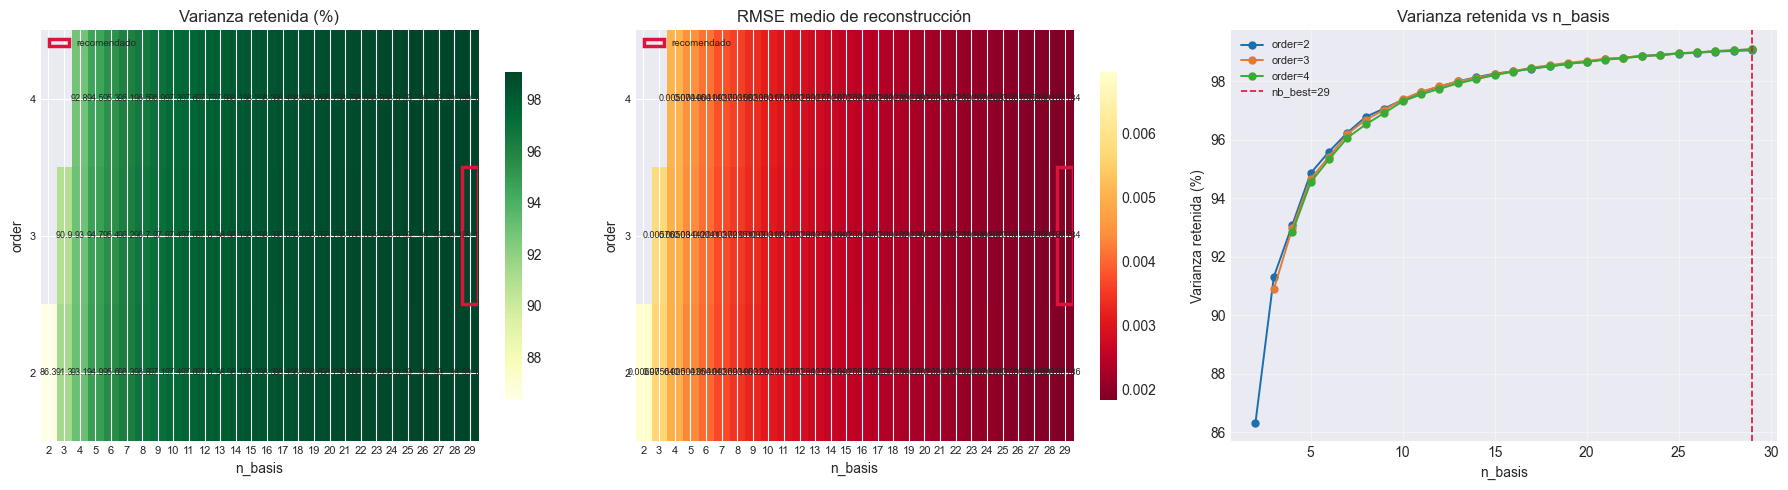

In [11]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")
if nb_best == max(N_BASIS_RANGE):
    print(f"! el mínimo está en el borde del rango (n_basis={nb_best}): el GCV pediría "
          "más funciones. No se amplía el rango; §3.6 muestra el piso de la base.")

plot_seleccion_basis(sel_df, nb_best, ord_best)
replicar_figura("05_seleccion_basis.png", PATHS_POR_M)
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

`X_SUAV = fr.reconstruct(THETA)` es el **objetivo de evaluación** (docs §03_05_00).

Base elegida : n_basis=29, order=3
Sugerido GCV : n_basis=29, order=3   (coinciden)
THETA (2434, 29)  (train=1703, test=731)
MISE(suavizada, observada) = 0.000004


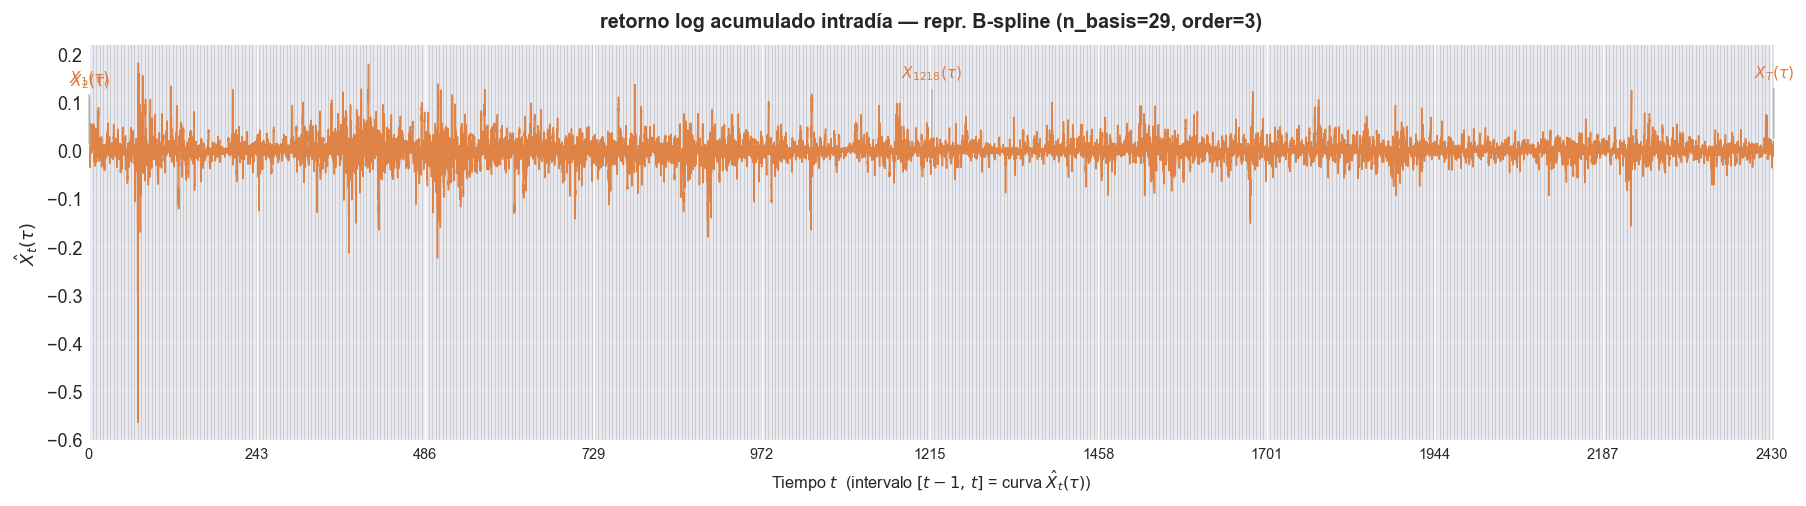

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 4 directorios)


In [12]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
X_SUAV      = fr.reconstruct(THETA)           # objetivo de evaluacion (docs 03_05_00)
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")
print(f"MISE(suavizada, observada) = {mise(X, X_SUAV, grilla):.6f}")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"{VARIABLE} — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

In [13]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 29
  K                                  = 29
  n_ajuste                           = 1703
  cond_W                             = 1.029e+01
  err_ortonormalidad_L2              = 2.776e-15
  err_ortonormalidad_gram            = 2.442e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 1.776e-15
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 2.307e-19
  err_media_scores_rel               = 4.941e-16
  err_var_scores_vs_lambda           = 1.220e-19
  err_var_scores_vs_lambda_rel       = 1.902e-13
  err_correlacion_lag0               = 1.549e-13
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok   

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,4.3858e-04,80.5891%,80.5891%,-0.096
1,2,5.3351e-05,9.8034%,90.3925%,-0.098
2,3,1.6884e-05,3.1025%,93.4950%,-0.034
3,4,1.0160e-05,1.8670%,95.3619%,-0.092
4,5,6.0210e-06,1.1064%,96.4683%,-0.058
5,6,3.6231e-06,0.6657%,97.1341%,-0.080
6,7,2.8795e-06,0.5291%,97.6632%,-0.088
7,8,2.1066e-06,0.3871%,98.0503%,-0.013
8,9,1.6621e-06,0.3054%,98.3557%,-0.011
9,10,1.3015e-06,0.2392%,98.5948%,-0.011



K disponibles: 29   ·   sugerencia (var ≥ 95%): M = 4
  M=1: var. acum = 80.5891%  ·  sensibilidad
  M=2: var. acum = 90.3925%  ·  sensibilidad
  M=3: var. acum = 93.4950%  ·  sensibilidad
  M=4: var. acum = 95.3619%  ·  regla del 95 %


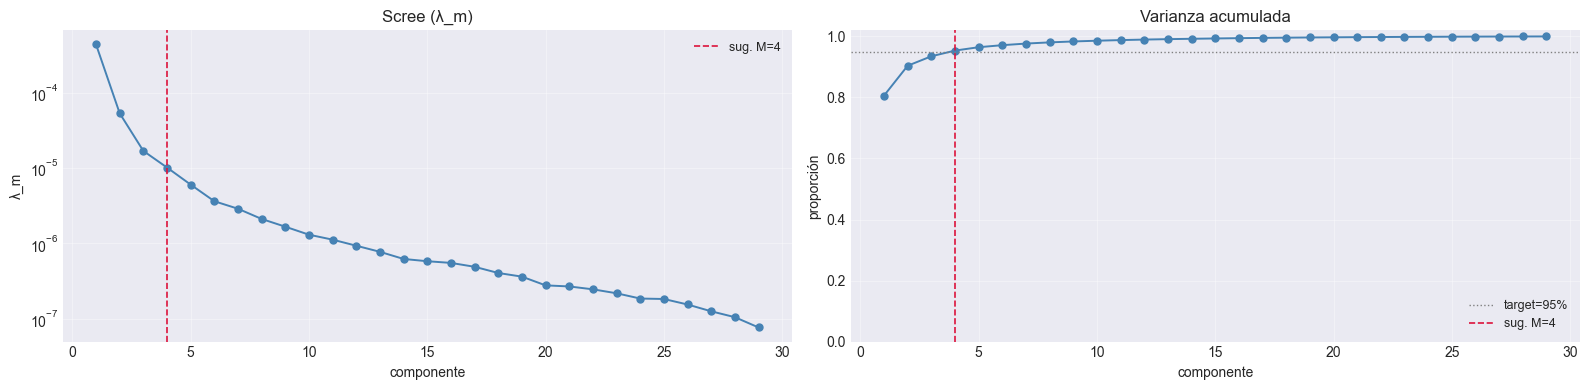

In [14]:
# Varianza != dinamica: una FPC de varianza baja puede tener AR fuerte.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

# K lo fija el GCV y ACOTA el barrido
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

### 3.4 Series de los componentes de la FPCA

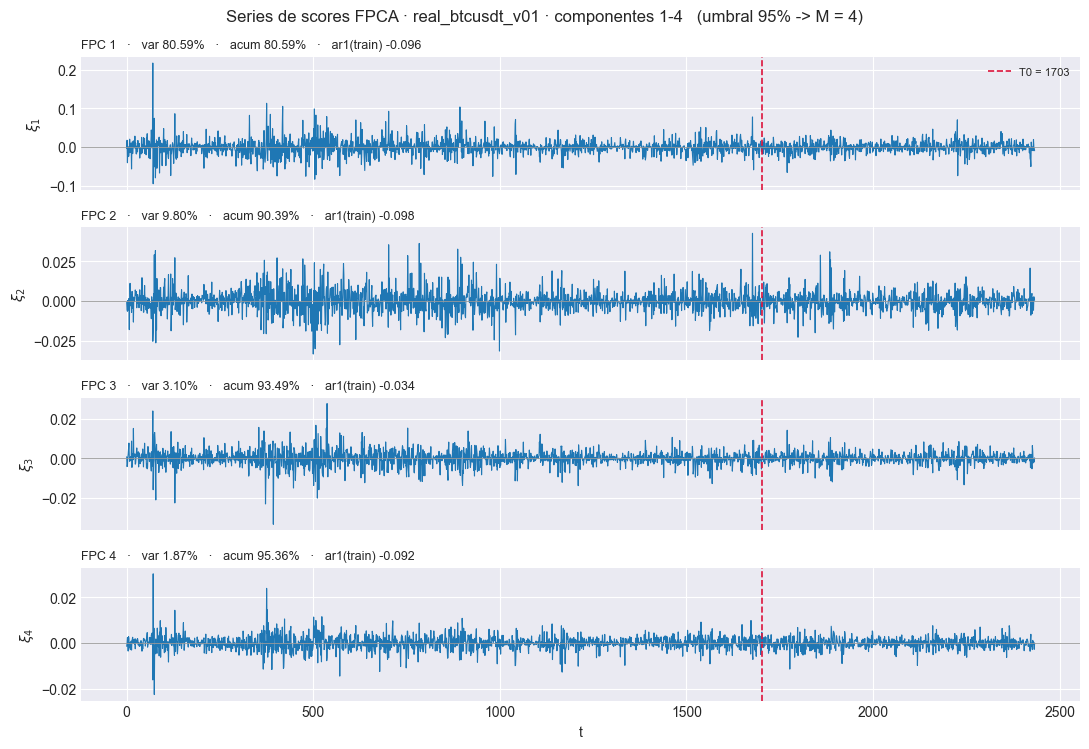

componentes graficadas : 1-4  de K = 29
var. acumulada hasta 4 : 95.3619%


In [15]:
# [CONFIG] hasta que componente se grafica: todas las del barrido.
N_SERIES_SCORES = max(M_FPCA_LIST)

assert 1 <= N_SERIES_SCORES <= K, f"N_SERIES_SCORES={N_SERIES_SCORES} fuera de [1, {K}]."

# B_full y no B: no depende de set_M. Serie completa, no solo train.
XI = (THETA - fpca.mu_theta) @ (fpca.W @ fpca.B_full)      # (T, K)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI[:, k], lw=0.8, color="C0")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    ax.set_ylabel(rf"$\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   var {fpca.var_ratio[k]:.2%}   ·   "
                 f"acum {fpca.var_cum[k]:.2%}   ·   ar1(train) {ar1[k]:+.3f}",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Series de scores FPCA · {EXPERIMENT_BASE} · componentes 1-"
             f"{N_SERIES_SCORES}   (umbral {VAR_TARGET:.0%} -> M = {M_SUGERIDO})")
fig.tight_layout()
replicar_figura("07b_fpca_scores_series.png", PATHS_POR_M)
plt.show()

print(f"componentes graficadas : 1-{N_SERIES_SCORES}  de K = {K}")
print(f"var. acumulada hasta {N_SERIES_SCORES} : {fpca.var_cum[N_SERIES_SCORES-1]:.4%}")

### 3.5 Componentes estandarizados — sólo contraste

Los scores **no** se estandarizan: a MATLAB van los de §3.4, en su escala propia. Esta sección muestra lo que se descartó.

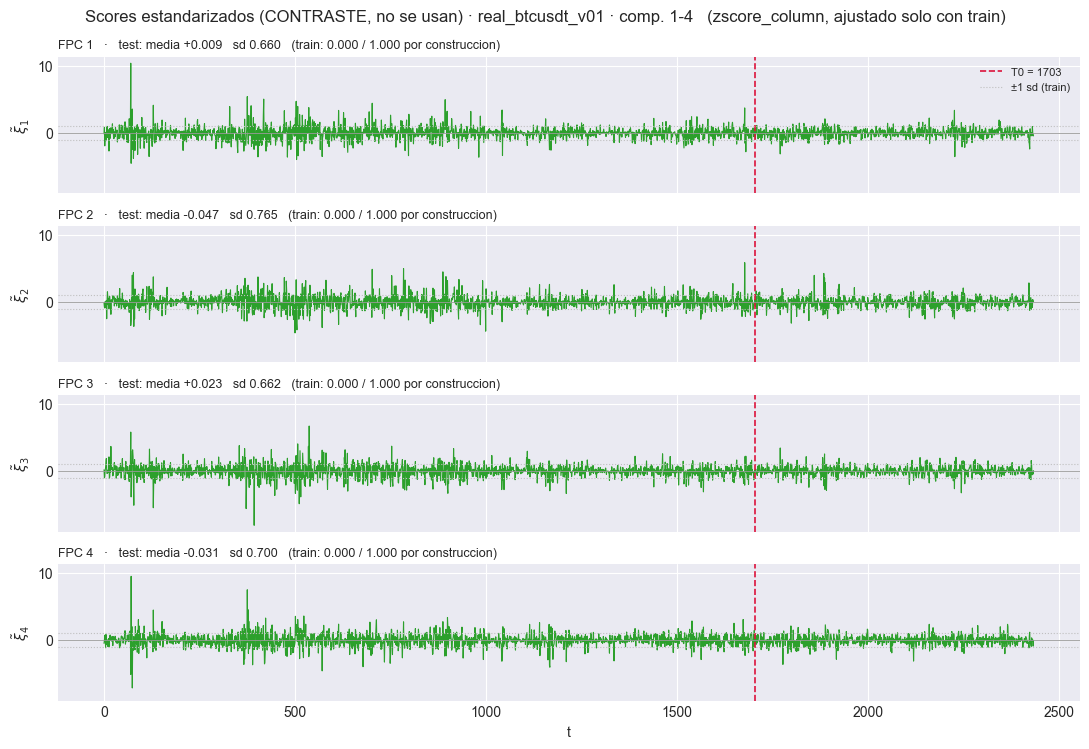

escala original  sd(train) : [0.0209 0.0073 0.0041 0.0032]
estandarizado    sd(test)  : [0.6604 0.7651 0.6618 0.6998]    <- lejos de 1 = el bloque de prueba no comparte escala con train


In [16]:
_std = DataStandardizer(method="zscore_column", ddof=0)
_std.fit(XI[idx_train, :N_SERIES_SCORES], etiqueta=f"train[1:{T0}]")
XI_STD = _std.transform(XI[:, :N_SERIES_SCORES])            # (T, N_SERIES_SCORES)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True, sharey=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI_STD[:, k], lw=0.8, color="C2")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    for _s in (-1, 1):
        ax.axhline(_s, color="0.75", ls=":", lw=0.8)
    ax.set_ylabel(rf"$\tilde\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   test: media {XI_STD[idx_test, k].mean():+.3f}   "
                 f"sd {XI_STD[idx_test, k].std():.3f}   "
                 f"(train: 0.000 / 1.000 por construccion)",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].plot([], [], color="0.75", ls=":", lw=0.8, label="±1 sd (train)")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Scores estandarizados (CONTRASTE, no se usan) · {EXPERIMENT_BASE} · comp. 1-"
             f"{N_SERIES_SCORES}   (zscore_column, ajustado solo con train)")
fig.tight_layout()
plt.show()

print(f"escala original  sd(train) : "
      f"{np.array2string(XI[idx_train, :N_SERIES_SCORES].std(0), precision=4)}")
print(f"estandarizado    sd(test)  : "
      f"{np.array2string(XI_STD[idx_test].std(0), precision=4)}"
      "    <- lejos de 1 = el bloque de prueba no comparte escala con train")

### 3.6 Comparación de las tres curvas: cruda, B-spline y FPCA$_M$

**Diagnóstico del preprocesamiento, no métrica reportable** (las diez de §02_02_03 se calculan en `_04`/`_05`).

| par | qué mide |
|---|---|
| MISE(cruda, B-spline) | piso de la base: **invariante en $M$** |
| MISE(cruda, FPCA$_M$) | error total de representación |
| MISE(B-spline, FPCA$_M$) | truncamiento FPCA: baja con $M$ |

La figura toma los días mejor, mediano y peor representados por FPCA$_M$ (con $M$=`M_REF_DIAS`) más el de mayor y menor volatilidad realizada, y superpone las tres curvas, un panel por $M$.

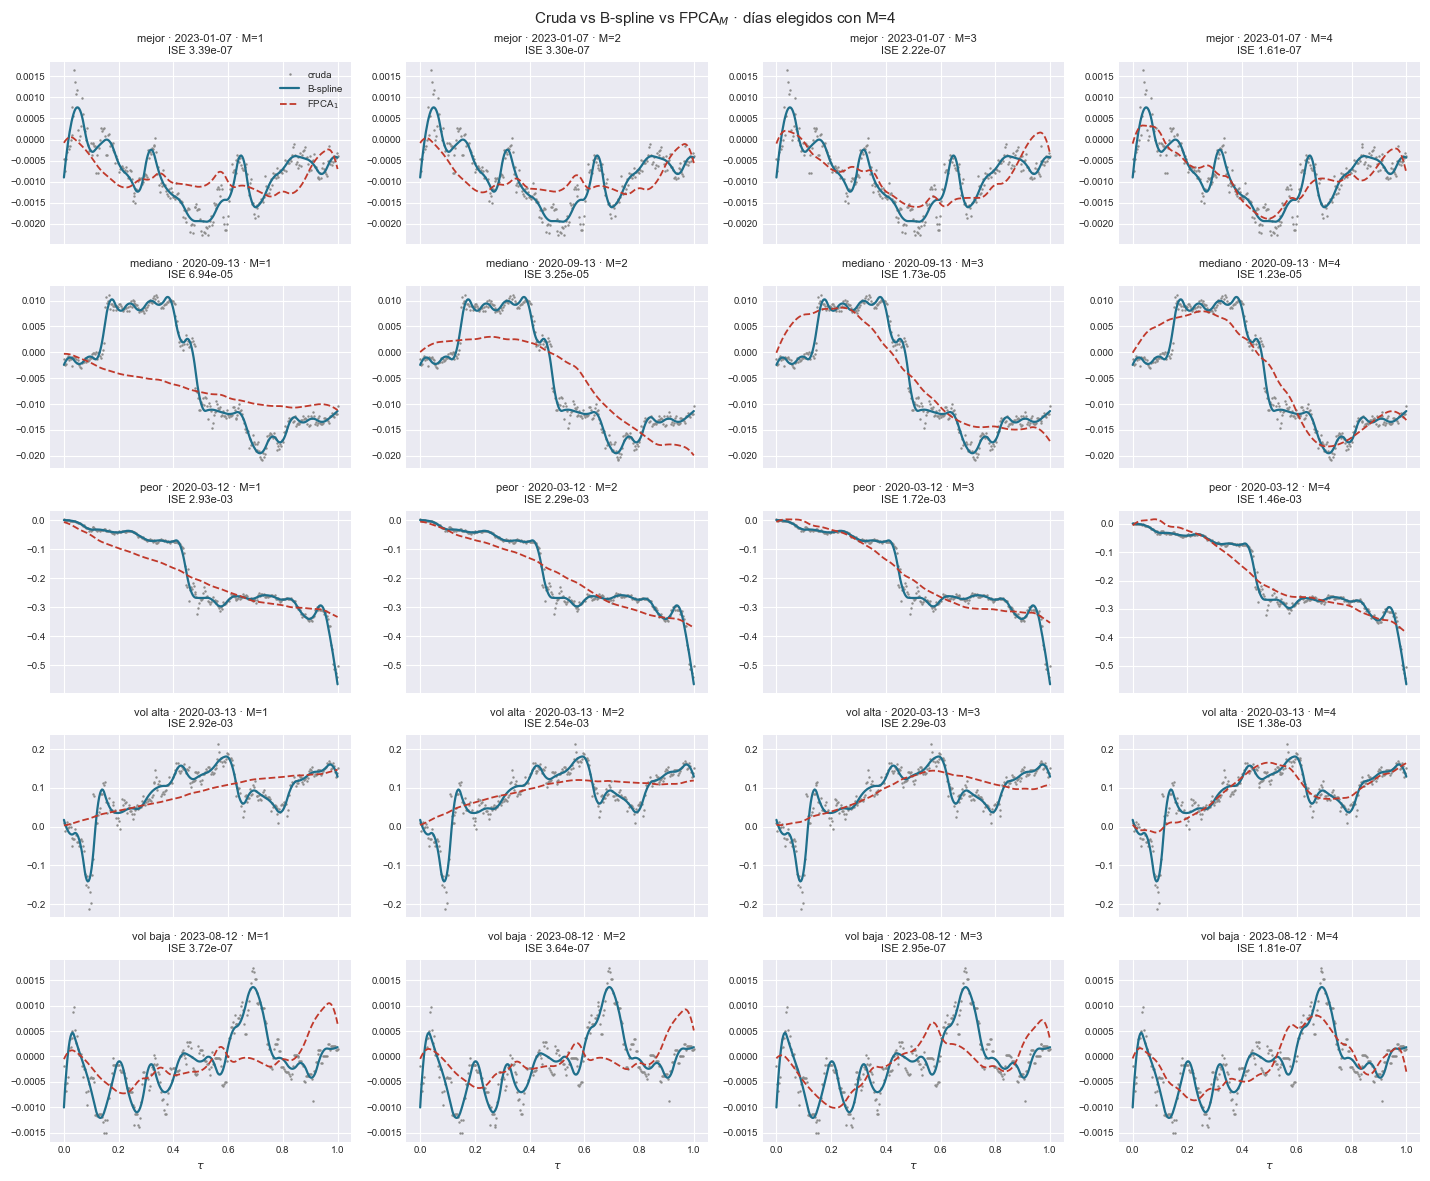

In [17]:
_w_tau = pesos_trapezoidales(grilla)
M_REF_DIAS = M_SUGERIDO if M_SUGERIDO in M_FPCA_LIST else min(M_FPCA_LIST)

X_FPCA = {}
filas_3c = []
for _M in M_FPCA_LIST:
    fpca.set_M(int(_M))
    X_FPCA[_M] = fpca.reconstruct(fpca.transform(THETA))      # (T, G)
    for bloque, _i in (("train", idx_train), ("test", idx_test)):
        _pc = mise(X[_i], X_SUAV[_i], grilla)
        _pf = mise(X[_i], X_FPCA[_M][_i], grilla)
        filas_3c.append({
            "M": int(_M), "bloque": bloque,
            "var_explicada": float(fpca.var_cum[_M - 1]),
            "mise_cruda_bspline": _pc,
            "mise_cruda_fpca": _pf,
            "mise_bspline_fpca": mise(X_SUAV[_i], X_FPCA[_M][_i], grilla),
            "frac_piso_base": _pc / _pf if _pf > 0 else np.nan,
        })

TRES_CURVAS = pd.DataFrame(filas_3c).set_index(["M", "bloque"])
for _p in PATHS_POR_M.values():
    TRES_CURVAS.to_csv(_p["out_report"] / "10_tres_curvas_mise.csv")
display(TRES_CURVAS.style
        .format({"var_explicada": "{:.4%}", "mise_cruda_bspline": "{:.3e}",
                 "mise_cruda_fpca": "{:.3e}", "mise_bspline_fpca": "{:.3e}",
                 "frac_piso_base": "{:.1%}"})
        .set_caption("Tres curvas · frac_piso_base = MISE(cruda, B-spline) / "
                     "MISE(cruda, FPCA_M) · diagnóstico, no métrica reportable"))

# Días de la figura: ISE por curva con la cuadratura común.
_ise = ((X - X_FPCA[M_REF_DIAS]) ** 2) @ _w_tau
_orden = np.argsort(_ise)
_cand = {"mejor": int(_orden[0]), "mediano": int(_orden[len(_orden) // 2]),
         "peor": int(_orden[-1]), "vol alta": int(np.argmax(VOL_DIA)),
         "vol baja": int(np.argmin(VOL_DIA))}
DIAS_3C = {}
for _nom, _i in _cand.items():
    if _i not in DIAS_3C.values():
        DIAS_3C[_nom] = _i

fig, axes = plt.subplots(len(DIAS_3C), len(M_FPCA_LIST),
                         figsize=(3.6 * len(M_FPCA_LIST), 2.4 * len(DIAS_3C)),
                         squeeze=False, sharex=True)
for r, (_nom, _i) in enumerate(DIAS_3C.items()):
    for c, _M in enumerate(M_FPCA_LIST):
        ax = axes[r, c]
        ax.plot(grilla, X[_i], ".", color="0.55", ms=1.5, label="cruda")
        ax.plot(grilla, X_SUAV[_i], color="#1f6f8b", lw=1.6, label="B-spline")
        ax.plot(grilla, X_FPCA[_M][_i], color="#c0392b", lw=1.3, ls="--",
                label=f"FPCA$_{{{_M}}}$")
        ax.set_title(f"{_nom} · {pd.Timestamp(DIAS[_i]).date()} · M={_M}\n"
                     f"ISE {(((X[_i] - X_FPCA[_M][_i]) ** 2) @ _w_tau):.2e}",
                     fontsize=8)
        ax.tick_params(labelsize=7)
axes[0, 0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel(r"$\tau$", fontsize=8)
fig.suptitle(f"Cruda vs B-spline vs FPCA$_M$ · días elegidos con M={M_REF_DIAS}",
             fontsize=11)
fig.tight_layout()
replicar_figura("10_tres_curvas.png", PATHS_POR_M, fig=fig)
plt.show()

## 4. El bucle sobre `M_FPCA_LIST`

- §4.1: `set_M(M)` y scores; contraste con la regla del 95 %
- §4.2: estandarizador en **identidad** (los scores van crudos) y artefactos FPCA
- §4.3: diagnóstico de rezagos sobre el bloque de entrenamiento
- §4.4: datasets AR con **rezago propio**
- §4.5: hiperparámetros y `mcmc_config` — el contrato con MATLAB
- §4.6: `eval_config`, líneas base y `verificar_contrato`

In [18]:
# E[tau] se declara como razon_Etau_lambda (= E[tau]*lambda_k, adimensional)
# o como e_tau_objetivo (literal, en 1/var(y)).
CLAVES_ETAU = ("razon_Etau_lambda", "e_tau_objetivo")


def clave_etau(escalera: dict) -> str:
    """La clave de E[tau] en uso, verificando que la escalera sea homogenea."""
    presentes = {c for pel in escalera.values() for c in CLAVES_ETAU if c in pel}
    if not presentes:
        raise KeyError(
            f"Ningun peldano de HP_ESCALERA declara E[tau]. Agrega una de "
            f"{CLAVES_ETAU} a cada uno.")
    if len(presentes) > 1:
        raise KeyError(
            f"HP_ESCALERA mezcla {sorted(presentes)}: los peldanos tienen que "
            "usar la MISMA convencion.")
    clave = presentes.pop()
    faltan = [k for k, pel in escalera.items() if clave not in pel]
    if faltan:
        raise KeyError(f"Peldanos de HP_ESCALERA sin {clave!r}: {sorted(faltan)}.")
    return clave


def e_tau_del_peldano(esc: dict, var_y_k: float) -> float:
    """E[tau] del peldano, cualquiera sea la convencion con que se declaro."""
    if "razon_Etau_lambda" in esc:
        return float(esc["razon_Etau_lambda"]) / max(var_y_k, 1e-12)
    return float(esc["e_tau_objetivo"])


def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_SUAV`— y no los recalcula:
    ésa es la garantía de que los puntos comparten datos y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = eid_de(M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Escala de los scores: SIN estandarizar --------------------------
    # Se ajusta con train (verificar_contrato exige n_ajuste == T0) y se deja en
    # identidad: MATLAB recibe los scores en su escala propia.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    MU_OBS = scores_standardizer.mean.copy()
    SD_OBS = scores_standardizer.std.copy()
    scores_standardizer.mean = np.zeros_like(MU_OBS)
    scores_standardizer.std  = np.ones_like(SD_OBS)

    SCORES_STD       = scores_standardizer.transform(SCORES)
    assert np.allclose(SCORES_STD, SCORES), "la transformacion deberia ser la identidad."
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}   (= SCORES: transformacion identidad)")
    print(f"  [train] media = {np.array2string(MU_OBS, precision=3)}   <- NO se resta")
    print(f"  [train] std   = {np.array2string(SD_OBS, precision=3)}   <- NO se divide")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")
    print(f"  rango que vera MATLAB: [{SCORES_STD.min():.3f}, {SCORES_STD.max():.3f}]")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi entregados (identicos: no se estandariza)"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------
    # Incluye los cruzados: muestra lo que el diseño de rezago propio descarta.
    N_LAGS_MAX = N_LAGS
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Datasets AR: SOLO rezago propio ---------------------------------
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    # cov_names en orden lag-mayor (lo exige _cols_orden del _05).
    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]
    cov_por_comp = {k: [f"fpc_{COMPONENT_IDX[k] + 1}_lag{lag}"
                        for lag in range(1, N_LAGS + 1)]
                    for k in range(n_components)}

    # Ninguna covariable de la componente k pertenece a otra componente.
    for k, covs in cov_por_comp.items():
        _duenos = {int(c.split("_")[1]) for c in covs}
        assert _duenos == {COMPONENT_IDX[k] + 1}, (
            f"FPC {COMPONENT_IDX[k] + 1} tiene covariables de otras componentes: {covs}")
        assert len(covs) == N_LAGS

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_por_comp[0])} covariable(s) por componente (rezago propio)")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_por_comp: {cov_por_comp}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores xi_k en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = np.column_stack([SCORES_sel[t_idx - lag, k] for lag in range(1, N_LAGS + 1)])
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_por_comp[k])

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "raw_fpca_scores",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "cov_por_componente": {str(k): cov_por_comp[k] for k in range(n_components)},
        "covariables":   "rezago_propio",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- §4.5 Hiperparametros y MCMC ------------------------------------------
    # Gating v_h(x) = Phi(alpha_h - sum_j psi_hj |x_j - Gamma_hj|). Discrimina por
    # la DISPERSION del argumento a traves de i, no por su media (alpha_h absorbe
    # la media, psbp_train.m:209-211). Presupuesto sd_gate/sqrt(p) por coordenada:
    #     mupsij_j  = (sd_gate / sqrt(p)) / sd_i |x_ij - Gamma_hj|
    #     taupsij_j = 1 / (cv_psi * mupsij_j)^2
    # Vectores por covariable, como ya los lee el .m. Se replica la grilla G* de
    # psbp_train.m (min/max GLOBALES de Xnoint) y el sorteo de Gammajh.
    _cal = []
    for _k in range(n_components):
        _Xk      = dfs_train[_k][cov_por_comp[_k]].to_numpy()
        _lo, _hi = float(_Xk.min()), float(_Xk.max())
        _Gstar   = _lo + (np.arange(1, MCMC_CONFIG["M"] + 1) / MCMC_CONFIG["M"]) * (_hi - _lo)
        _Gam     = np.random.default_rng(SEED + _k).choice(
            _Gstar, size=(MCMC_CONFIG["N"] - 1, _Xk.shape[1]))
        _D       = np.abs(_Xk[None, :, :] - _Gam[:, None, :])
        _cal.append({"Xk": _Xk, "Gstar": _Gstar,
                     "escala": float(_D.sum(-1).mean()),
                     "spread": _D.std(axis=1).mean(axis=0),
                     "media":  _D.mean(axis=(0, 1))})
        print(f"FPC {COMPONENT_IDX[_k] + 1}: G* = [{_lo:.3f}, {_hi:.3f}]   "
              f"sd_i|x - Gamma| = {np.array2string(_cal[-1]['spread'], precision=4)}")

    # Todas las covariables son rezagos PROPIOS; el tipo sale del nombre.
    def _clasificar(nombre, k_modelo):
        lag = int(nombre.rsplit("_lag", 1)[1])
        assert nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag{lag}", (
            f"{nombre} no es rezago propio de la componente {k_modelo}.")
        return f"own_lag{lag}"

    def _beta_pi(nombre, k_modelo):
        cfg = HP_BY_TYPE[_clasificar(nombre, k_modelo)]
        return float(cfg["apij"]), float(cfg["bpij"])

    # Escape del estado absorbente w_j = 0 (psbp_train.m:202-221).
    def _escape(apij, bpij, pwj, N):
        b_val = math.exp(math.lgamma(bpij + N) + math.lgamma(apij + bpij)
                         - math.lgamma(bpij) - math.lgamma(apij + bpij + N))
        return pwj * b_val / ((1 - pwj) + pwj * b_val)

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        esc       = HP_ESCALERA[k]
        mupsij_k  = (esc["sd_gate_objetivo"] / math.sqrt(len(cov_por_comp[k]))) / _cal[k]["spread"]
        taupsij_k = 1.0 / (esc["cv_psi"] * mupsij_k) ** 2
        _ab       = [_beta_pi(nm, k) for nm in cov_por_comp[k]]

        # btau = atau / E[tau]; sin piso (la cota var(residuo) <= var(y) es del
        # promedio de la mezcla, no de cada atomo).
        var_y_k = float(SCORES_train[:, k].var(ddof=0))
        E_tau_k = e_tau_del_peldano(esc, var_y_k)
        btau_k  = esc["atau"] / E_tau_k

        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "atau": float(esc["atau"]), "btau": float(btau_k),
            "apij":    np.array([a for a, _ in _ab], dtype=float),
            "bpij":    np.array([b for _, b in _ab], dtype=float),
            "mupsij":  np.asarray(mupsij_k,  dtype=float),
            "taupsij": np.asarray(taupsij_k, dtype=float)})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB si se entrena este M")

    def _aviso_etau(razon):
        frac = 1.0 / max(razon, 1e-12)      # varianza residual, en unidades de lambda_k
        if frac > 5.0:
            return (f"   <- el prior cree {frac:.0f}x la varianza del score: "
                    "banda ANCHA")
        if frac < 0.33:
            return (f"   <- el prior cree solo {frac:.2f} de la varianza: "
                    "riesgo de SUBCOBERTURA")
        return ""

    # `sd real` es la dispersion del argumento probit que queda: < 0.3 no discrimina.
    print(f"  {'k':>2} {'fpc':>4} {'sd_gate':>8} {'sd real':>8} {'media arg':>10} "
          f"{'cv_psi':>7} {'Etau*lam':>9} {'var(y)':>9} {'E[tau]':>8} {'btau':>9}")
    for k in range(n_components):
        hp, esc = HYPERPARAMS_LIST[k], HP_ESCALERA[k]
        _v    = float(SCORES_train[:, k].var(ddof=0))
        _sd   = float(np.sqrt(((hp["mupsij"] * _cal[k]["spread"]) ** 2).sum()))
        _med  = float((hp["mupsij"] * _cal[k]["media"]).sum())
        _flag = "   <- gating DEBIL" if _sd < 0.3 else ""
        print(f"  {k:>2} {COMPONENT_IDX[k]+1:>4} {esc['sd_gate_objetivo']:>8.2f} "
              f"{_sd:>8.2f} {_med:>10.2f} {esc['cv_psi']:>7.2f} "
              f"{(hp['atau'] / hp['btau']) * _v:>9.2f} {_v:>9.5f} "
              f"{hp['atau']/hp['btau']:>8.2f} {hp['btau']:>9.5f}"
              + _aviso_etau((hp['atau'] / hp['btau']) * _v) + _flag)

    # Peso del prior sobre psi: taupsij / (taupsij + sum_i (x_ij - Gamma_hj)^2).
    _peso = []
    for k in range(n_components):
        _kh   = _cal[k]["Xk"].shape[0] / MCMC_CONFIG["N"]
        _info = _kh * ((_cal[k]["Xk"] - _cal[k]["Gstar"][len(_cal[k]["Gstar"]) // 2]) ** 2).mean(axis=0)
        _peso.append(float(np.mean(HYPERPARAMS_LIST[k]["taupsij"]
                                   / (HYPERPARAMS_LIST[k]["taupsij"] + _info))))
    _peso = np.array(_peso)
    print(f"\npeso del prior sobre psi por componente = "
          f"{np.array2string(_peso * 100, precision=1)} %"
          "   (>30 % = psi clavado en mupsij, gating congelado)")

    print(f"\n  {'k':>2} {'covariable':>16} {'tipo':>10} {'apij':>6} {'bpij':>6} "
          f"{'E[pi]':>7} {'P(escape)':>10} {'espera':>8}")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        for j, nm in enumerate(cov_por_comp[k]):
            a, b = hp["apij"][j], hp["bpij"][j]
            pe   = _escape(a, b, HP_GLOBAL["pwj"], MCMC_CONFIG["N"])
            flag = "  <- > nsim" if 1 / pe > MCMC_CONFIG["nsim"] else ""
            print(f"  {k:>2} {nm:>16} {_clasificar(nm, k):>10} {a:>6.3f} {b:>6.3f} "
                  f"{a/(a+b):>7.3f} {pe:>10.2e} {1/pe:>8.0f}{flag}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "escalera":     {str(k): HP_ESCALERA[k] for k in range(n_components)},
        "escala_probit": [c["escala"] for c in _cal],
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "serie_id":     SERIE_ID,
        "ventana_id":   int(VENTANA_ID),
        "m_fpca":       int(M),
        "m_entrenamiento": int(M_ENTRENO),
        "trazas_en":    eid_de(M_ENTRENO),
        "covariables":  "rezago_propio",
        "seed_base":    int(SEED),     # MATLAB la lee de aquí
        "scores_scale": "raw_fpca_scores",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "raw_fpca_scores",
        "fuente":              f"datos observados (Binance {PAR} {INTERVALO})",
        "curva":               CURVA,
        "variable":            VARIABLE,
        # docs 03_05_00: ninguno es la grilla cruda.
        #   principal  : curva suavizada = representacion B-spline de la observada
        #   secundario : X_t^(M), la expansion truncada; solo metodos sobre scores
        "objetivo_evaluacion": "curva_suavizada",
        "objetivo_secundario": "representacion_fpca",
        # Forzado por el modelo, no es perilla: la variabilidad vive en la mezcla.
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [20, 30, 40], "paso": 1, "solapadas": True},
        # Las metricas del marco teorico 02_02_03, y solo esas.
        "metricas_bloque_A": ["mae_f", "rmse_f", "linf_medio", "linf_max"],
        "metricas_bloque_B": ["mpiw", "picp", "picp_simultaneo", "winkler",
                              "winkler_max_medio", "winkler_max_glob"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_SUAV, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva SUAVIZADA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_por_comp[0])),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }

HP_BY_TYPE = apij=1, bpij=5 (Chung & Dunson) para own_lag1..4  ·  N=40  escape=0.100 (espera~10 iter)  E[pi]=0.167
escalera de la curva 'retorno_acumulado'

escalera por componente (btau se despeja en procesar_punto):
   k  sd_gate  cv_psi   atau  razon_Etau_lambda
   0     1.20    0.70   2.50               1.00
   1     1.20    0.70   2.00               1.00
   2     1.20    0.70   2.00               1.00
   3     1.20    0.70   2.00               1.00

N_LAGS      : 4
MCMC_CONFIG : {'nsim': 5000, 'burn': 2000, 'N': 40, 'M': 60}   (su 'M' es la grilla G* del stick-breaking)
N_CHAINS    : 2
Draws posteriores por score: (5000 - 2000) x 2 = 6000

M = 1   ·   real_btcusdt_v01_m01
M(95 %) según la regla : 4   (K disponible = 29)
M de este punto        : 1   <- DIFIERE de la regla: es un punto de sensibilidad
M = 1   var. explicada = 80.5891%
[train] max|media xi| = 3.59e-19   (~ 0)
[test]  max|media xi| = 0.000
[test]  var xi / lambda = [0.436]
[holdout] ajustado con 1703 filas = T0 (train

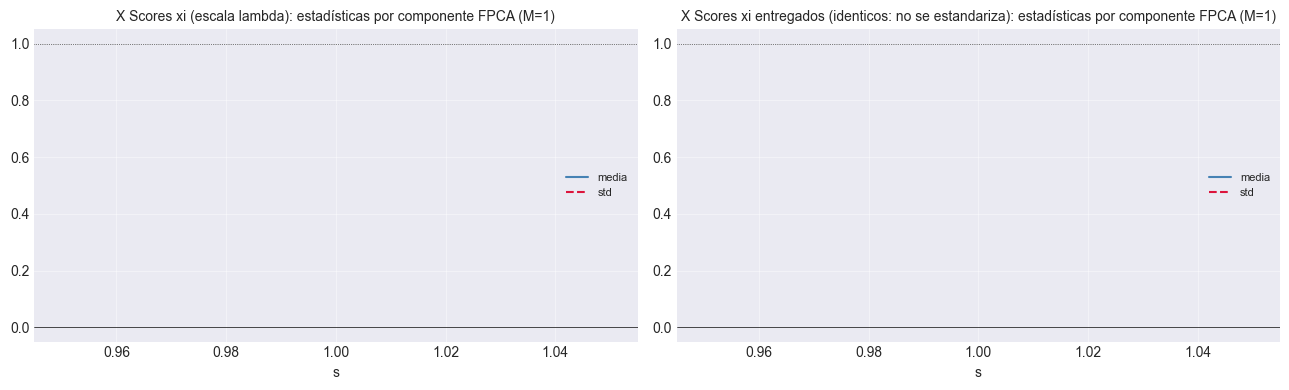

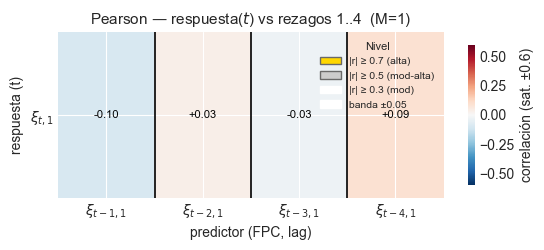

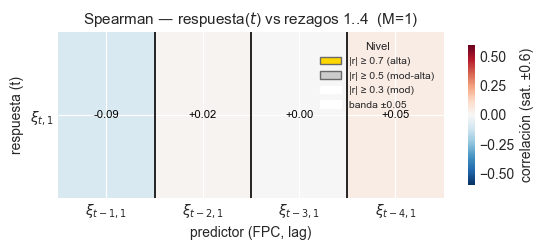

componentes : 1 -> índices [0]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 1699   n_test_eff : 731
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_1_lag2', 'fpc_1_lag3', 'fpc_1_lag4']}
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (1699, 5) · test (731, 5)
FPC 1: G* = [-0.095, 0.217]   sd_i|x - Gamma| = [0.0195 0.0199 0.0193 0.0195]

N_CHAINS = 2 cadenas por componente -> 2 jobs en MATLAB si se entrena este M
   k  fpc  sd_gate  sd real  media arg  cv_psi  Etau*lam    var(y)   E[tau]      btau
   0    1     1.20     1.20      12.69    0.70      1.00   0.00044  2281.45   0.00110

peso del prior sobre psi por componente = [1.] %   (>30 % = psi clavado en mupsij, gating congelado)

   k       covariable       tipo   apij   bpij   E[pi]  P(escape)   espera
   0       fpc_1_lag1   own_lag1  1.000  5.000   0.167   1.00e-01       10
   0       fpc_1_lag2   own_lag2  1.000  5.000   0.167   1.00e-01       10
   0       fpc_1_lag3   own_lag3  1.

,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,731.0000,0.0138,0.0138,-0.0002,0.0002,0.0157
persistencia_lag1,731.0000,0.0197,0.0197,-1.0205,0.0004,0.0210


contrato_ok = True   (M=1, K=29, T0=1703, n_components=1)
estandarizador ajustado con 1703 filas (T0=1703)
verificación FPCA: todo_ok = True

M = 2   ·   real_btcusdt_v01_m02
M(95 %) según la regla : 4   (K disponible = 29)
M de este punto        : 2   <- DIFIERE de la regla: es un punto de sensibilidad
M = 2   var. explicada = 90.3925%
[train] max|media xi| = 1.86e-19   (~ 0)
[test]  max|media xi| = 0.000
[test]  var xi / lambda = [0.436 0.586]
[holdout] ajustado con 1703 filas = T0 (train[1:1703]) -> ok=True

SCORES_STD (2434, 2)   (= SCORES: transformacion identidad)
  [train] media = [-1.080e-19  1.856e-19]   <- NO se resta
  [train] std   = [0.021 0.007]   <- NO se divide
  [test]  media = [ 0. -0.]
  [test]  std   = [0.014 0.006]
  rango que vera MATLAB: [-0.095, 0.217]

[functional] artefactos FPCA · cond_W = 1.029e+01


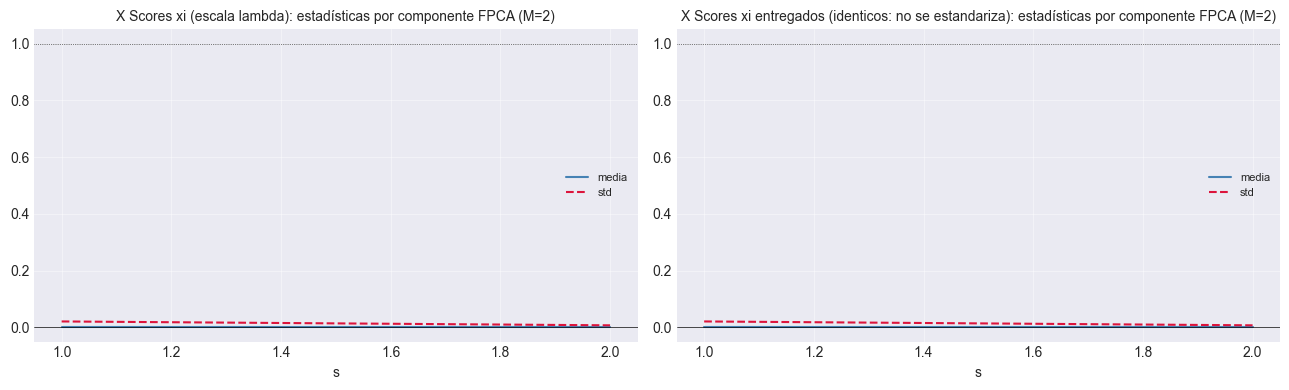

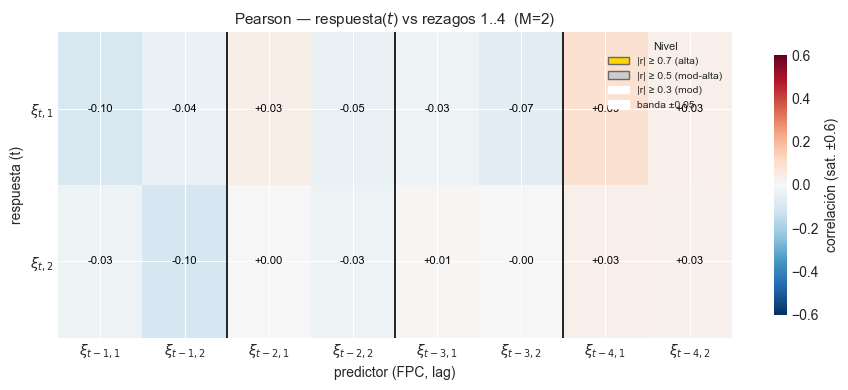

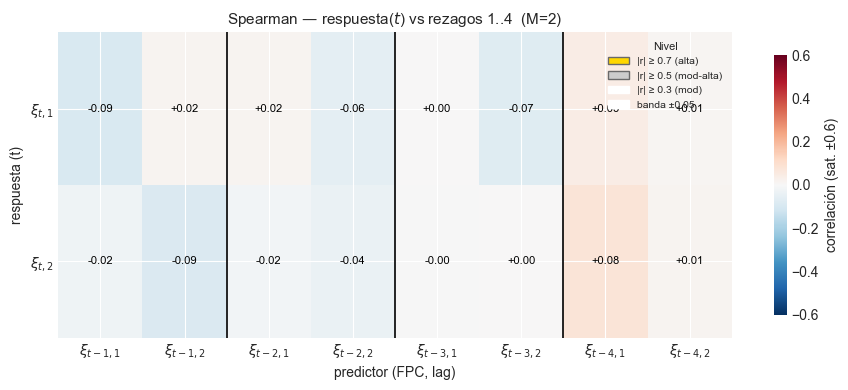

componentes : 2 -> índices [0, 1]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 1699   n_test_eff : 731
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_1_lag2', 'fpc_1_lag3', 'fpc_1_lag4'], 1: ['fpc_2_lag1', 'fpc_2_lag2', 'fpc_2_lag3', 'fpc_2_lag4']}
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (1699, 5) · test (731, 5)
  fpc_2: train (1699, 5) · test (731, 5)
FPC 1: G* = [-0.095, 0.217]   sd_i|x - Gamma| = [0.0195 0.0199 0.0193 0.0195]
FPC 2: G* = [-0.034, 0.043]   sd_i|x - Gamma| = [0.0065 0.0065 0.0068 0.0066]

N_CHAINS = 2 cadenas por componente -> 4 jobs en MATLAB si se entrena este M
   k  fpc  sd_gate  sd real  media arg  cv_psi  Etau*lam    var(y)   E[tau]      btau
   0    1     1.20     1.20      12.69    0.70      1.00   0.00044  2281.45   0.00110
   1    2     1.20     1.20       7.37    0.70      1.00   0.00005 18754.80   0.00011

peso del prior sobre psi por componente = [1.  6.2] %   (>30 % = psi clavado en mupsij, gating

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,731.0000,0.0138,0.0056,0.0097,-0.0020,0.0002,0.0157
persistencia_lag1,731.0000,0.0197,0.0082,0.0139,-1.0888,0.0005,0.0218


contrato_ok = True   (M=2, K=29, T0=1703, n_components=2)
estandarizador ajustado con 1703 filas (T0=1703)
verificación FPCA: todo_ok = True

M = 3   ·   real_btcusdt_v01_m03
M(95 %) según la regla : 4   (K disponible = 29)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 93.4950%
[train] max|media xi| = 1.86e-19   (~ 0)
[test]  max|media xi| = 0.000
[test]  var xi / lambda = [0.436 0.586 0.438]
[holdout] ajustado con 1703 filas = T0 (train[1:1703]) -> ok=True

SCORES_STD (2434, 3)   (= SCORES: transformacion identidad)
  [train] media = [-1.080e-19  1.856e-19 -4.380e-20]   <- NO se resta
  [train] std   = [0.021 0.007 0.004]   <- NO se divide
  [test]  media = [ 1.936e-04 -3.407e-04  9.254e-05]
  [test]  std   = [0.014 0.006 0.003]
  rango que vera MATLAB: [-0.095, 0.217]

[functional] artefactos FPCA · cond_W = 1.029e+01


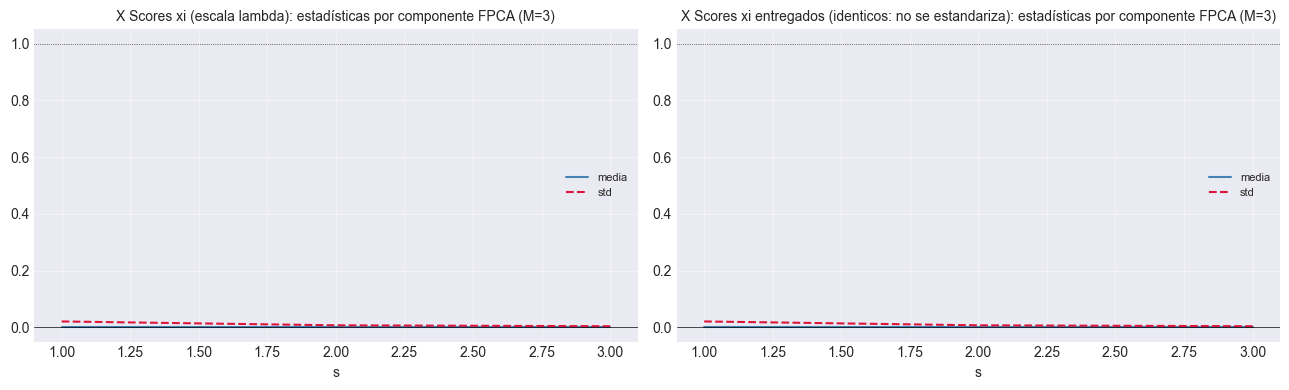

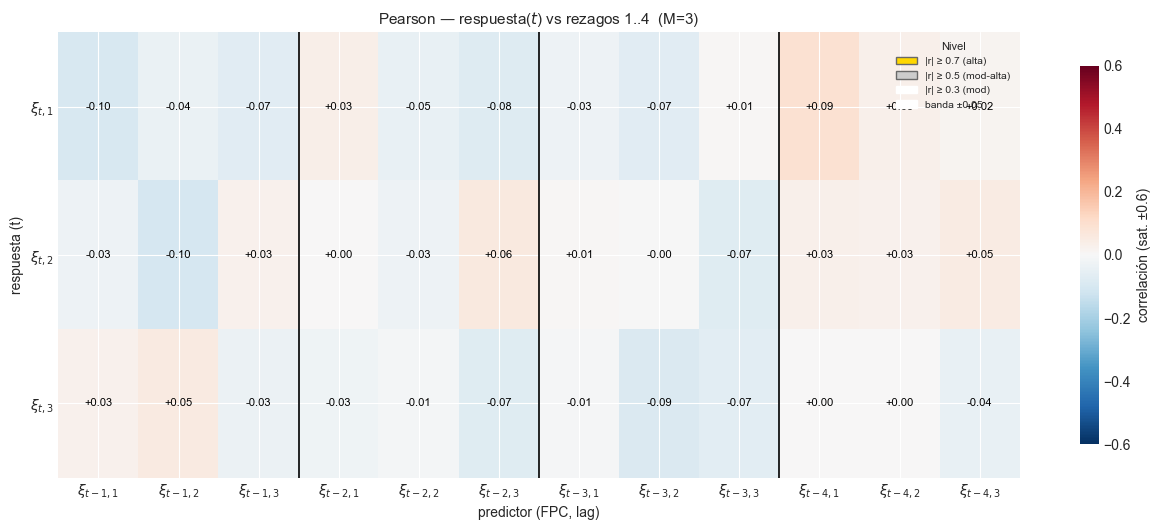

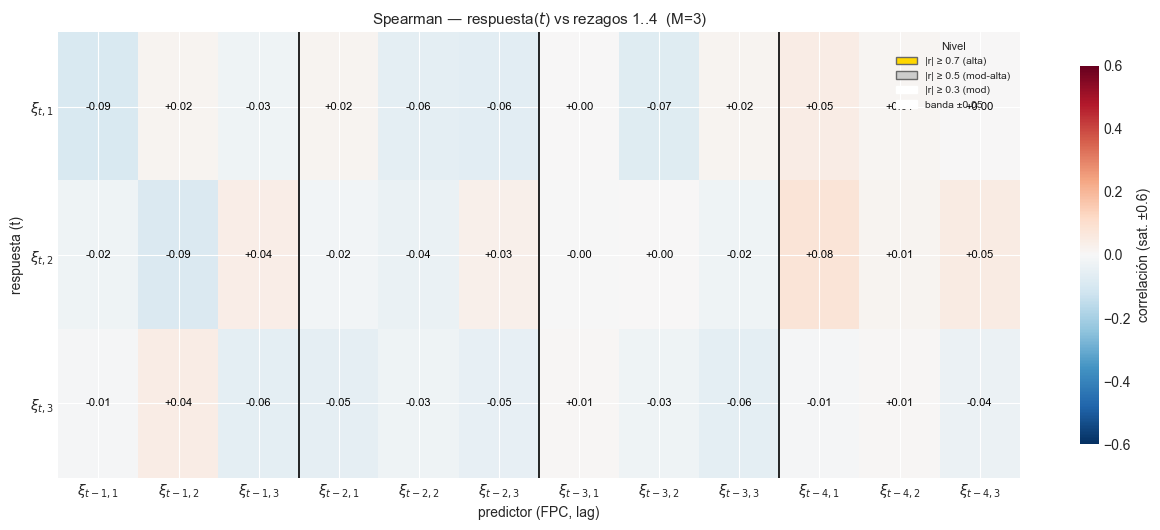

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 1699   n_test_eff : 731
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_1_lag2', 'fpc_1_lag3', 'fpc_1_lag4'], 1: ['fpc_2_lag1', 'fpc_2_lag2', 'fpc_2_lag3', 'fpc_2_lag4'], 2: ['fpc_3_lag1', 'fpc_3_lag2', 'fpc_3_lag3', 'fpc_3_lag4']}
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (1699, 5) · test (731, 5)
  fpc_2: train (1699, 5) · test (731, 5)
  fpc_3: train (1699, 5) · test (731, 5)
FPC 1: G* = [-0.095, 0.217]   sd_i|x - Gamma| = [0.0195 0.0199 0.0193 0.0195]
FPC 2: G* = [-0.034, 0.043]   sd_i|x - Gamma| = [0.0065 0.0065 0.0068 0.0066]
FPC 3: G* = [-0.033, 0.028]   sd_i|x - Gamma| = [0.0038 0.0038 0.0038 0.0038]

N_CHAINS = 2 cadenas por componente -> 6 jobs en MATLAB si se entrena este M
   k  fpc  sd_gate  sd real  media arg  cv_psi  Etau*lam    var(y)   E[tau]      btau
   0    1     1.20     1.20      12.69    0.70      1.00   0.00044  2281.45   0.0011

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,731.0000,0.0138,0.0056,0.0027,0.0074,-0.0017,0.0002,0.0157
persistencia_lag1,731.0000,0.0197,0.0082,0.0039,0.0106,-1.0766,0.0005,0.0220


contrato_ok = True   (M=3, K=29, T0=1703, n_components=3)
estandarizador ajustado con 1703 filas (T0=1703)
verificación FPCA: todo_ok = True

M = 4   ·   real_btcusdt_v01_m04
M(95 %) según la regla : 4   (K disponible = 29)
M de este punto        : 4   (coincide con la regla)
M = 4   var. explicada = 95.3619%
[train] max|media xi| = 1.86e-19   (~ 0)
[test]  max|media xi| = 0.000
[test]  var xi / lambda = [0.436 0.586 0.438 0.49 ]
[holdout] ajustado con 1703 filas = T0 (train[1:1703]) -> ok=True

SCORES_STD (2434, 4)   (= SCORES: transformacion identidad)
  [train] media = [-1.080e-19  1.856e-19 -4.380e-20 -1.935e-20]   <- NO se resta
  [train] std   = [0.021 0.007 0.004 0.003]   <- NO se divide
  [test]  media = [ 1.936e-04 -3.407e-04  9.254e-05 -9.728e-05]
  [test]  std   = [0.014 0.006 0.003 0.002]
  rango que vera MATLAB: [-0.095, 0.217]

[functional] artefactos FPCA · cond_W = 1.029e+01


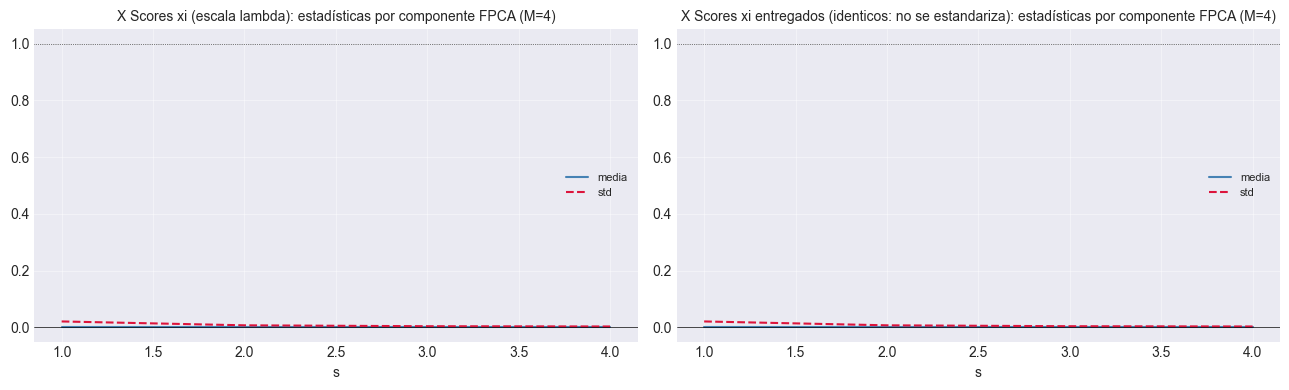

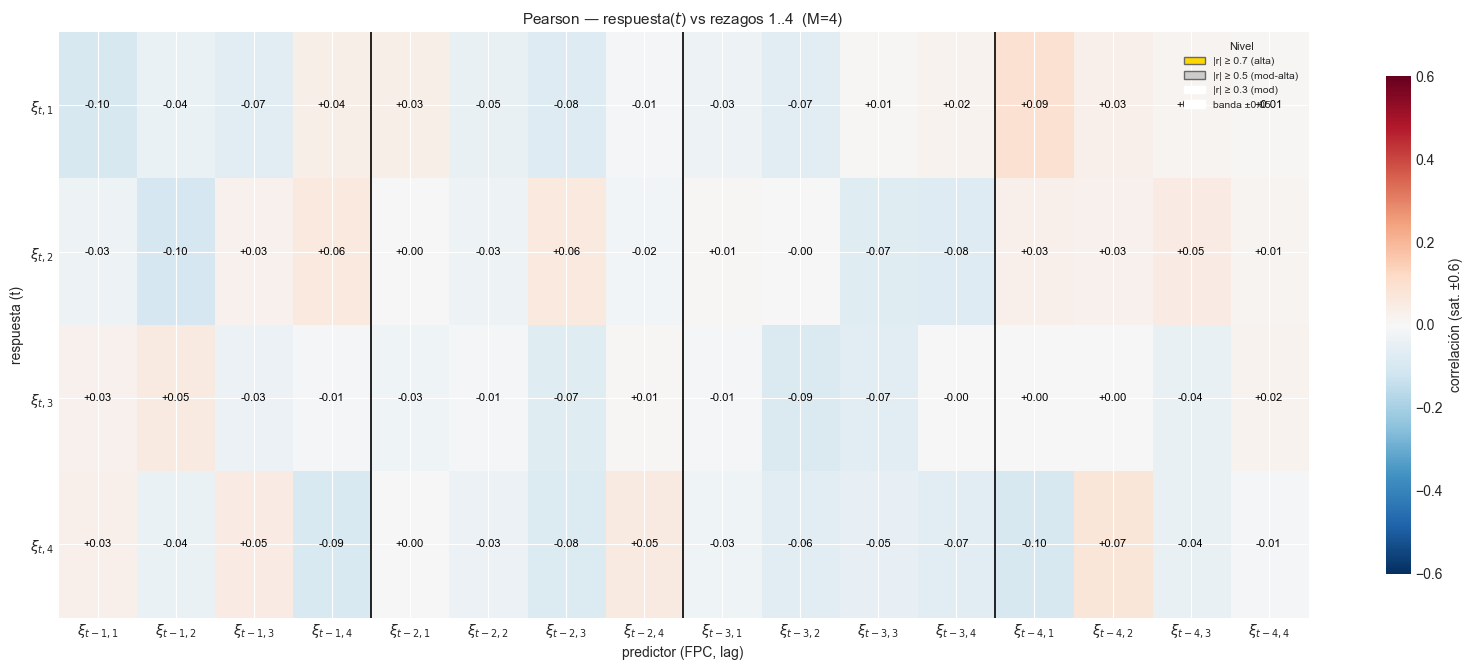

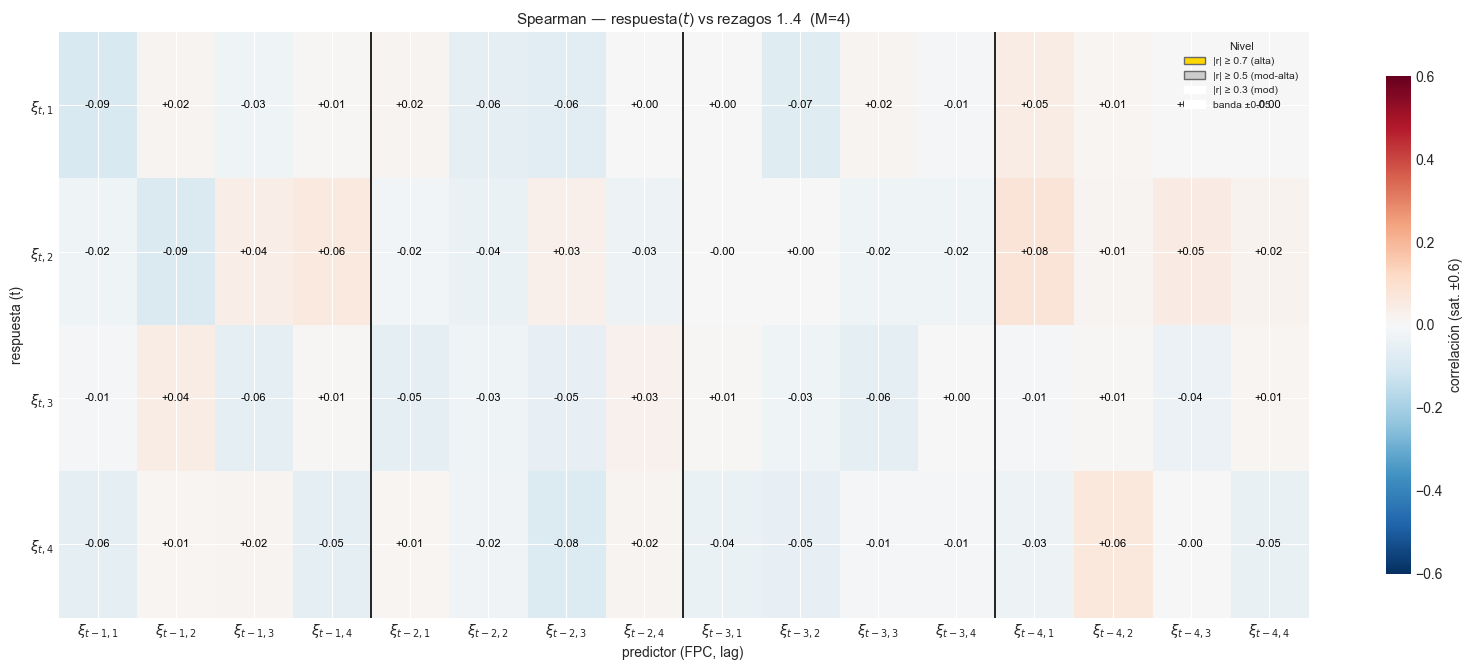

componentes : 4 -> índices [0, 1, 2, 3]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 1699   n_test_eff : 731
cov_por_comp: {0: ['fpc_1_lag1', 'fpc_1_lag2', 'fpc_1_lag3', 'fpc_1_lag4'], 1: ['fpc_2_lag1', 'fpc_2_lag2', 'fpc_2_lag3', 'fpc_2_lag4'], 2: ['fpc_3_lag1', 'fpc_3_lag2', 'fpc_3_lag3', 'fpc_3_lag4'], 3: ['fpc_4_lag1', 'fpc_4_lag2', 'fpc_4_lag3', 'fpc_4_lag4']}
[functional] 8 datasets + datasets_manifest.json
  fpc_1: train (1699, 5) · test (731, 5)
  fpc_2: train (1699, 5) · test (731, 5)
  fpc_3: train (1699, 5) · test (731, 5)
  fpc_4: train (1699, 5) · test (731, 5)
FPC 1: G* = [-0.095, 0.217]   sd_i|x - Gamma| = [0.0195 0.0199 0.0193 0.0195]
FPC 2: G* = [-0.034, 0.043]   sd_i|x - Gamma| = [0.0065 0.0065 0.0068 0.0066]
FPC 3: G* = [-0.033, 0.028]   sd_i|x - Gamma| = [0.0038 0.0038 0.0038 0.0038]
FPC 4: G* = [-0.023, 0.030]   sd_i|x - Gamma| = [0.0029 0.003  0.0029 0.0029]

N_CHAINS = 2 cadenas por componente -> 8 jobs en MATLAB si se en

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,731.0000,0.0138,0.0056,0.0027,0.0022,0.0061,-0.0017,0.0002,0.0157
persistencia_lag1,731.0000,0.0197,0.0082,0.0039,0.0032,0.0087,-1.0701,0.0005,0.0221


contrato_ok = True   (M=4, K=29, T0=1703, n_components=4)
estandarizador ajustado con 1703 filas (T0=1703)
verificación FPCA: todo_ok = True


In [21]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
# Rezagos PROPIOS: la componente k se predice con xi_{k,t-1..t-N_LAGS} y nada
# mas; p = N_LAGS en todas las componentes. 7 = una semana de dias.
N_LAGS_ADMITIDOS = (1, 2, 3, 4)
N_LAGS      = 4
assert N_LAGS in N_LAGS_ADMITIDOS, f"N_LAGS admitido: {N_LAGS_ADMITIDOS} (ver HP_BY_TYPE)."

# La del 24.
MCMC_CONFIG = {"nsim": 5000, "burn": 2000, "N": 40, "M": 60}   # ojo: ese M es G*
N_CHAINS    = 2

# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Inclusion: apij=1, bpij=5 CONSTANTE (references/Case1_01.m, Chung & Dunson
# 2009), sin escalera por rezago. Con apij=1 y pwj=0.5 el escape de w_j=0 es
# bpij/(N + 2*bpij).
HP_BY_TYPE = {f"own_lag{l}": {"apij": 1.0, "bpij": 5.0} for l in N_LAGS_ADMITIDOS}
_N_ATOMOS = MCMC_CONFIG["N"]
_escape_chung = 5.0 / (_N_ATOMOS + 10.0)
print(f"HP_BY_TYPE = apij=1, bpij=5 (Chung & Dunson) para own_lag1..{max(N_LAGS_ADMITIDOS)}  ·  "
      f"N={_N_ATOMOS}  escape={_escape_chung:.3f} (espera~{1/_escape_chung:.0f} iter)  "
      f"E[pi]={1/6:.3f}")

# sd_gate_objetivo  dispersion deseada del argumento probit.
# cv_psi            sd(psi)/E(psi) a priori.
# razon_Etau_lambda E[tau]*lambda_k: 1/razon es la varianza residual por atomo
#                   que cree el prior, en unidades de lambda_k.
#
# retorno_acumulado: la de 103_sim_A3 (A-3). xi_k es casi ruido blanco en media
#   (R^2 AR(7) de train <= 0.02 en k=1..5): razon 1.0; la dependencia es de
#   escala, y sd_gate 1.2 / cv_psi 0.7 refuerzan el gating.
# log_parkinson: k=0 es el nivel de volatilidad del dia, persistente (R^2 AR(7)
#   de train 0.77, residuo ~0.23 lambda_1): gating del 101 y razon 2.0, prior
#   ~2x por encima del residuo lineal. k>=1: R^2 AR(7) <= 0.18, como el retorno.
# atau > 1 para que exista la sd predictiva.
_PELDANO_RUIDO = {"sd_gate_objetivo": 1.2, "cv_psi": 0.7,
                  "atau": 2.0, "razon_Etau_lambda": 1.0}
ESCALERAS = {
    "retorno_acumulado": {0: {"sd_gate_objetivo": 1.2, "cv_psi": 0.7,
                              "atau": 2.5, "razon_Etau_lambda": 1.0},
                          **{k: dict(_PELDANO_RUIDO) for k in range(1, 8)}},
    "log_parkinson":     {0: {"sd_gate_objetivo": 0.8, "cv_psi": 1.0,
                              "atau": 2.5, "razon_Etau_lambda": 2.0},
                          **{k: dict(_PELDANO_RUIDO) for k in range(1, 8)}},
}
# log_precio y retorno_barra son solo referencia: usan la del retorno acumulado.
HP_ESCALERA = ESCALERAS.get(CURVA, ESCALERAS["retorno_acumulado"])
print(f"escalera de la curva {CURVA!r}"
      + ("" if CURVA in ESCALERAS else "  (la de retorno_acumulado, sin calibrar)"))

assert all(k in HP_ESCALERA for k in range(max(M_FPCA_LIST))), (
    f"HP_ESCALERA necesita peldanos 0..{max(M_FPCA_LIST) - 1} para "
    f"M_FPCA_LIST={list(M_FPCA_LIST)}.")

_CLAVE_ETAU = clave_etau({k: HP_ESCALERA[k] for k in range(max(M_FPCA_LIST))})

print("\nescalera por componente (btau se despeja en procesar_punto):")
print(f"  {'k':>2} {'sd_gate':>8} {'cv_psi':>7} {'atau':>6} {_CLAVE_ETAU:>18}")
for _k in range(max(M_FPCA_LIST)):
    _e = HP_ESCALERA[_k]
    print(f"  {_k:>2} {_e['sd_gate_objetivo']:>8.2f} {_e['cv_psi']:>7.2f} "
          f"{_e['atau']:>6.2f} {_e[_CLAVE_ETAU]:>18.2f}")

print(f"\nN_LAGS      : {N_LAGS}")
print(f"MCMC_CONFIG : {MCMC_CONFIG}   (su 'M' es la grilla G* del stick-breaking)")
print(f"N_CHAINS    : {N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]

## 5. Resumen del barrido

In [22]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"con M_FPCA_LIST = [{M_ENTRENO}]   (solo se entrena M={M_ENTRENO}: "
      f"los M menores reutilizan sus trazas)\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,real_btcusdt_v01_m01,80.5891%,29,False,1,4,True
2,real_btcusdt_v01_m02,90.3925%,29,False,2,4,True
3,real_btcusdt_v01_m03,93.4950%,29,False,3,4,True
4,real_btcusdt_v01_m04,95.3619%,29,True,4,4,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [4]   (solo se entrena M=4: los M menores reutilizan sus trazas)
